# Benchmarking PPO, SAC and TD3 for Generalizable Robotic Arm Manipulation in MuJoCo

**An online reinforcement-learning benchmark.** Three continuous-control algorithms — PPO, SAC
and TD3 — each learn a pick-and-place task on a simulated 4-DoF robotic arm in MuJoCo, from
scratch, by interacting with the simulator and generating all of their own experience.

> There is **no dataset, no demonstration, no offline buffer and no behaviour cloning** anywhere
> in this project. The simulator produces every transition the agents learn from.

**Research question.** Under an identical task, reward, observation space, action space and
environment-step budget, how do PPO, SAC and TD3 compare on **final success rate**, **sample
efficiency**, **training stability**, and **generalisation to environment configurations never
encountered during training**?

### What this notebook does, in order

1. install dependencies → 2. imports and GL backend → 3. configure the experiment →
4. write the project modules → 5. build the environment → 6. verify it → 7. render a sample scene →
8. train PPO → 9. train SAC → 10. train TD3 → 11. validation evaluation → 12. compare algorithms →
13. **select** the winner on validation → 14. **freeze** the configuration →
15. evaluate on the untouched test set → 16. generalisation → 17. robustness → 18. ablations →
19. benchmark tables → 20. plots → 21. render the final policy → 22. save everything →
23. final summary.

### Compute

Pick a preset in section 3. `smoke` (~5 min) checks that everything runs; `quick` (~40 min) gives a
real but weak result; `standard` (~2–3 h) is the recommended setting; `full` (~8–12 h) gives the
strongest statistics. A GPU runtime helps but is not required.

---
## 1. Install dependencies

Colab already ships PyTorch, NumPy, pandas, SciPy and matplotlib; we add the simulation and RL stack.

In [1]:
!pip -q install "mujoco>=3.1,<4" "gymnasium>=1.0,<2" "stable-baselines3>=2.6" \
                "imageio>=2.31" "imageio-ffmpeg>=0.4.9" "tabulate>=0.9" 2>&1 | tail -2

# Software OpenGL, so that rendering also works on a CPU-only runtime.
# Skipped when an NVIDIA device is present, where hardware EGL is used instead.
import subprocess, shutil
if not shutil.which("nvidia-smi"):
    print("no GPU detected -- installing the software renderer (takes ~30 s)")
    !apt-get -qq install -y libosmesa6-dev libgl1-mesa-glx > /dev/null 2>&1

print("dependencies ready")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 16.9 MB/s eta 0:00:00
dependencies ready


---
## 2. Imports and the offscreen OpenGL backend

MuJoCo needs an offscreen GL backend to render, and `MUJOCO_GL` has to be set **before** `mujoco`
is first imported — hence this cell comes before any other import of the simulator.

Each candidate backend is tested in a **subprocess**. This matters: a failed EGL initialisation on a
machine without a usable GPU driver aborts the process instead of raising a Python exception, so
probing backends in-process can kill the kernel outright (*"Your session crashed for an unknown
reason"*). Only a backend confirmed working in a throwaway subprocess is ever selected here.

If no backend works the notebook still runs end to end — training and evaluation do not render.
Only the video cells are skipped, and they say so.

In [2]:
import os, sys, json, time, math, random, dataclasses, warnings
warnings.filterwarnings("ignore")

import subprocess

_GL_PROBE = (
    "import os,sys;os.environ['MUJOCO_GL']=sys.argv[1];"
    "os.environ.setdefault('PYOPENGL_PLATFORM',sys.argv[1]);import mujoco;"
    "m=mujoco.MjModel.from_xml_string("
    "\"<mujoco><worldbody><geom type='sphere' size='.1'/></worldbody></mujoco>\");"
    "r=mujoco.Renderer(m,64,64);r.update_scene(mujoco.MjData(m));r.render();r.close();"
    "print('ok')"
)

def setup_gl(candidates=("egl", "osmesa", "glfw"), verbose=True):
    # Each backend is probed in a SUBPROCESS. A failed EGL init on a machine without a
    # usable GPU driver aborts the process rather than raising, so an in-process probe
    # loop can kill the kernel. A subprocess crash costs nothing.
    for backend in candidates:
        try:
            p = subprocess.run([sys.executable, "-c", _GL_PROBE, backend],
                               capture_output=True, timeout=120)
        except Exception:
            continue
        if p.returncode == 0 and b"ok" in p.stdout:
            os.environ["MUJOCO_GL"] = backend
            os.environ.setdefault("PYOPENGL_PLATFORM", backend)
            if verbose:
                print(f"offscreen rendering: {backend}"
                      + (" (software, slower)" if backend == "osmesa" else ""))
            return backend
        if verbose:
            print(f"  {backend}: unavailable")
    os.environ["MUJOCO_GL"] = "disabled"
    if verbose:
        print("No offscreen renderer available. Training and evaluation still work; "
              "the video cells will be skipped.")
    return "unavailable"

GL_BACKEND = setup_gl()

import numpy as np, pandas as pd, torch, mujoco, gymnasium as gym
import matplotlib.pyplot as plt
import stable_baselines3 as sb3
from IPython.display import display, HTML, Image, Markdown

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"mujoco {mujoco.__version__} | gymnasium {gym.__version__} | sb3 {sb3.__version__} | "
      f"torch {torch.__version__}")
print(f"GL backend: {GL_BACKEND} | device: {DEVICE}")

offscreen rendering: egl


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


mujoco 3.13.0 | gymnasium 1.3.0 | sb3 2.9.0 | torch 2.11.0+cu128
GL backend: egl | device: cuda


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---
## 3. The code

The notebook is the **only** file you need. Nothing is cloned, downloaded or written to disk —
every class and function below is defined directly in the notebook namespace, in dependency order.

The code is grouped into the sections it would occupy in a package, so it stays navigable:

| section | responsibility |
|---|---|
| 3.1 Configuration | every hyper-parameter, randomisation range and compute preset |
| 3.2 Scene | the MuJoCo MJCF model (arm, table, cube, target) |
| 3.3 Environment | the Gymnasium environment and episode-configuration sampling |
| 3.4 Evaluation | the evaluation suite and the validation callback |
| 3.5 Training | PPO/SAC/TD3 training across seeds |
| 3.6 Analysis | aggregation, statistics, benchmark tables |
| 3.7 Plots | every figure |
| 3.8 Video | offscreen rendering of evaluation episodes |
| 3.9 Experiments | generalisation, robustness, ablations |
| 3.10 Pipeline | output layout, the split, model selection |

### 3.1 Configuration — the single source of truth for every tunable value

Seeds, budgets, environment parameters, algorithm hyper-parameters, evaluation episode counts and randomisation ranges all live here. Nothing is hard-coded elsewhere in the project, and the whole object is serialised to JSON next to the results it produced.

In [3]:
"""Centralised configuration for the PPO / SAC / TD3 MuJoCo manipulation benchmark.

Every tunable number in the project lives here.  Nothing is hard-coded in the
environment, training or evaluation code.  A configuration can be serialised to
JSON so that any result directory contains the exact settings that produced it.
"""
from __future__ import annotations

import dataclasses
import json
from dataclasses import dataclass, field, asdict
from typing import Dict, List, Optional, Tuple

# --------------------------------------------------------------------------- #
# Reward
# --------------------------------------------------------------------------- #


@dataclass
class RewardConfig:
    """Weights of every reward component (see README for the rationale)."""

    w_reach: float = 1.0          # penalty on ||ee - object|| while not holding
    w_transport: float = 1.2      # penalty on ||object - target||
    w_action: float = 0.05        # penalty on mean(a^2), discourages bang-bang control
    w_time: float = 0.05          # constant per-step penalty, encourages speed
    w_collision: float = 0.10     # penalty when an arm link touches the table/floor
    w_drop: float = 1.0           # penalty for releasing the object far from the target
    b_grasp: float = 5.0          # one-off bonus the first time the object is grasped
    b_place: float = 10.0         # bonus for releasing the object above the target
    b_success: float = 25.0       # terminal bonus for a completed pick-and-place
    p_object_lost: float = 10.0   # penalty if the object leaves the table

    # Ablation switches (used by the reward ablation study).
    use_reach_term: bool = True
    use_transport_term: bool = True
    use_grasp_bonus: bool = True


# --------------------------------------------------------------------------- #
# Environment
# --------------------------------------------------------------------------- #


@dataclass
class EnvConfig:
    """Simulation, task, observation and randomisation settings."""

    # --- simulation -------------------------------------------------------- #
    frame_skip: int = 5                 # physics steps per agent step (dt = 0.02 s)
    max_episode_steps: int = 200        # 4 s of simulated time
    ctrl_scale: float = 0.09            # rad added to a joint position target per unit action
    finger_travel: float = 0.035        # m of finger opening

    # --- task -------------------------------------------------------------- #
    grasp_radius: float = 0.05          # ee-object distance under which a close command grasps
    success_threshold: float = 0.05     # object-target distance for success (m)
    success_speed: float = 0.20         # object must be nearly at rest to count as placed
    place_bonus_radius: float = 0.08    # releasing inside this radius earns the placement bonus
    table_height: float = 0.0           # z of the table surface
    object_half_size: float = 0.022

    # --- observation ------------------------------------------------------- #
    obs_mode: str = "full"              # "joint_only" | "joint_ee" | "full"
    obs_noise_std: float = 0.0          # Gaussian noise added to the (normalised) observation

    # --- episode randomisation (the "environment configuration") ----------- #
    object_radius_range: Tuple[float, float] = (0.24, 0.40)
    object_angle_range: Tuple[float, float] = (-1.0, 1.0)     # rad about the +x axis
    target_radius_range: Tuple[float, float] = (0.24, 0.40)
    target_angle_range: Tuple[float, float] = (-1.0, 1.0)
    object_yaw_range: Tuple[float, float] = (-3.14159, 3.14159)
    object_mass_range: Tuple[float, float] = (0.04, 0.08)
    min_object_target_dist: float = 0.12
    init_joint_noise: float = 0.15      # rad of noise on the home configuration
    home_qpos: Tuple[float, float, float, float] = (0.0, 0.60, 1.90, 0.60)

    def replace(self, **kw) -> "EnvConfig":
        return dataclasses.replace(self, **kw)


# --------------------------------------------------------------------------- #
# Algorithms
# --------------------------------------------------------------------------- #


@dataclass
class AlgoConfig:
    """Hyper-parameters for one algorithm.

    ``net_arch``, ``learning_rate``, ``gamma`` and the training budget are kept
    identical across the three algorithms so that the comparison is fair; only
    the parameters that are intrinsic to each family differ.
    """

    name: str
    n_envs: int = 1
    kwargs: Dict = field(default_factory=dict)


def default_algo_configs(net_arch: Optional[List[int]] = None,
                         gamma: float = 0.98,
                         learning_rate: float = 3e-4) -> Dict[str, AlgoConfig]:
    net_arch = net_arch or [256, 256]
    return {
        "PPO": AlgoConfig(
            name="PPO",
            n_envs=8,  # PPO is on-policy: parallel envs only change how steps are gathered
            kwargs=dict(
                policy="MlpPolicy",
                learning_rate=learning_rate,
                n_steps=512,          # 512 * 8 envs = 4096 transitions per update
                batch_size=256,
                n_epochs=10,
                gamma=gamma,
                gae_lambda=0.95,
                clip_range=0.2,
                ent_coef=0.0,
                vf_coef=0.5,
                max_grad_norm=0.5,
                policy_kwargs=dict(net_arch=dict(pi=net_arch, vf=net_arch)),
            ),
        ),
        "SAC": AlgoConfig(
            name="SAC",
            n_envs=1,
            kwargs=dict(
                policy="MlpPolicy",
                learning_rate=learning_rate,
                buffer_size=300_000,
                learning_starts=2_000,
                batch_size=256,
                tau=0.005,
                gamma=gamma,
                train_freq=1,
                gradient_steps=1,
                ent_coef="auto",
                policy_kwargs=dict(net_arch=net_arch),
            ),
        ),
        "TD3": AlgoConfig(
            name="TD3",
            n_envs=1,
            kwargs=dict(
                policy="MlpPolicy",
                learning_rate=learning_rate,
                buffer_size=300_000,
                learning_starts=2_000,
                batch_size=256,
                tau=0.005,
                gamma=gamma,
                train_freq=1,
                gradient_steps=1,
                policy_delay=2,
                target_policy_noise=0.2,
                target_noise_clip=0.5,
                action_noise_sigma=0.15,  # consumed by the trainer, not by SB3 directly
                policy_kwargs=dict(net_arch=net_arch),
            ),
        ),
    }


# --------------------------------------------------------------------------- #
# Experiment
# --------------------------------------------------------------------------- #


@dataclass
class ExperimentConfig:
    """Top-level experiment description."""

    run_name: str = "arm_benchmark"
    output_dir: str = "outputs"

    algorithms: Tuple[str, ...] = ("PPO", "SAC", "TD3")
    total_timesteps: int = 150_000
    seeds: Tuple[int, ...] = (0, 1, 2)

    # Split seeds.  Training episodes are drawn from an independent RNG stream;
    # validation and test configurations are fixed, disjoint, held-out sets.
    train_seed_base: int = 100_000
    val_config_seed: int = 777_000
    test_config_seed: int = 999_000
    n_val_configs: int = 30           # full validation set (model selection)
    n_val_configs_during_training: int = 10   # cheap subset used by the callback
    n_test_configs: int = 60          # untouched until the final evaluation
    n_generalization_configs: int = 40
    n_robustness_configs: int = 25

    eval_freq: int = 10_000           # env steps between validation evaluations
    success_threshold_for_sample_efficiency: float = 0.5

    # Expensive optional studies.
    run_generalization: bool = True
    run_robustness: bool = True
    run_ablation: bool = True
    ablation_timesteps: int = 60_000
    ablation_seeds: Tuple[int, ...] = (0, 1)
    ablation_obs_modes: Tuple[str, ...] = ("joint_only", "joint_ee", "full")
    run_reward_ablation: bool = True

    # Video
    n_demo_episodes: int = 3
    video_fps: int = 50
    video_width: int = 640
    video_height: int = 480

    env: EnvConfig = field(default_factory=EnvConfig)
    reward: RewardConfig = field(default_factory=RewardConfig)
    algo_overrides: Dict = field(default_factory=dict)

    # ------------------------------------------------------------------ #
    def to_json(self, path: str) -> None:
        with open(path, "w") as f:
            json.dump(self.as_dict(), f, indent=2)

    def as_dict(self) -> Dict:
        d = asdict(self)
        d["algorithms"] = list(self.algorithms)
        d["seeds"] = list(self.seeds)
        return d


# --------------------------------------------------------------------------- #
# Presets — let the user trade compute for statistical power in one line.
# --------------------------------------------------------------------------- #

PRESETS: Dict[str, Dict] = {
    # ~2 minutes: only checks that every code path executes.
    "smoke": dict(
        total_timesteps=4_000, seeds=(0,), eval_freq=2_000,
        n_val_configs=6, n_val_configs_during_training=4, n_test_configs=8,
        n_generalization_configs=5, n_robustness_configs=4,
        ablation_timesteps=2_500, ablation_seeds=(0,), n_demo_episodes=1,
        run_reward_ablation=False,
    ),
    # ~25-40 minutes on a Colab CPU/GPU runtime.
    "quick": dict(
        total_timesteps=50_000, seeds=(0, 1), eval_freq=5_000,
        n_val_configs=20, n_val_configs_during_training=8, n_test_configs=30,
        n_generalization_configs=20, n_robustness_configs=15,
        ablation_timesteps=25_000, ablation_seeds=(0,), n_demo_episodes=2,
        run_reward_ablation=False,
    ),
    # ~2-3 hours.  This is the default and the setting we recommend reporting.
    "standard": dict(
        total_timesteps=150_000, seeds=(0, 1, 2), eval_freq=10_000,
        n_val_configs=30, n_val_configs_during_training=10, n_test_configs=60,
        n_generalization_configs=40, n_robustness_configs=25,
        ablation_timesteps=60_000, ablation_seeds=(0, 1), n_demo_episodes=3,
    ),
    # ~8-12 hours.  Five seeds, the statistically strongest configuration.
    "full": dict(
        total_timesteps=400_000, seeds=(0, 1, 2, 3, 4), eval_freq=20_000,
        n_val_configs=50, n_val_configs_during_training=12, n_test_configs=100,
        n_generalization_configs=60, n_robustness_configs=40,
        ablation_timesteps=150_000, ablation_seeds=(0, 1, 2), n_demo_episodes=4,
    ),
}


def make_config(preset: str = "standard", **overrides) -> ExperimentConfig:
    """Build an :class:`ExperimentConfig` from a preset plus explicit overrides."""
    if preset not in PRESETS:
        raise ValueError(f"unknown preset {preset!r}; choose from {list(PRESETS)}")
    cfg = ExperimentConfig(**PRESETS[preset])
    for k, v in overrides.items():
        if not hasattr(cfg, k):
            raise ValueError(f"unknown config field {k!r}")
        setattr(cfg, k, v)
    return cfg

### 3.2 The MuJoCo scene

A 4-DoF revolute arm on a pedestal, a two-finger gripper, a free-floating cube and a target marker, written inline as MJCF. Writing the model as a string rather than downloading an asset is what makes the notebook reliable in a fresh Colab runtime.

In [4]:
"""MuJoCo model for the benchmark.

A compact 4-DoF revolute arm (yaw + three pitch joints) mounted on a pedestal in
the middle of a table, a two-finger gripper, one free-floating cube and a visual
target site.  The model is written as a string so the notebook is completely
self-contained: no external mesh or asset download is required, which is exactly
what makes it reliable inside a fresh Colab runtime.

Design notes
------------
* ``gravcomp="1"`` on the arm links models an industrially standard gravity
  compensation loop.  Without it the position servos droop and every algorithm
  spends its budget learning to fight gravity instead of learning the task.
* The fingers and the palm are **non-colliding** (``contype=0 conaffinity=0``).
  Grasping is abstracted (see :mod:`rlbench.env`), so contact-rich finger/cube
  interaction would only add solver noise without adding task content.
* The arm links *do* collide with the table and with the cube, so the collision
  penalty is meaningful.
"""

ARM_XML = """
<mujoco model="arm_pick_place">
  <compiler angle="radian" autolimits="true"/>
  <option timestep="0.004" gravity="0 0 -9.81" integrator="implicitfast"/>

  <visual>
    <headlight ambient="0.45 0.45 0.45" diffuse="0.55 0.55 0.55" specular="0.1 0.1 0.1"/>
    <global azimuth="135" elevation="-22" offwidth="1280" offheight="960"/>
    <map znear="0.01" zfar="20"/>
    <quality shadowsize="2048"/>
  </visual>

  <asset>
    <texture name="skybox" type="skybox" builtin="gradient"
             rgb1="0.35 0.45 0.60" rgb2="0.08 0.10 0.14" width="256" height="256"/>
    <texture name="grid" type="2d" builtin="checker" rgb1="0.20 0.21 0.23"
             rgb2="0.26 0.27 0.30" width="300" height="300"/>
    <material name="grid" texture="grid" texrepeat="8 8" reflectance="0.05"/>
    <material name="table_mat" rgba="0.78 0.72 0.63 1" reflectance="0.05"/>
    <material name="arm_mat"   rgba="0.30 0.36 0.46 1"/>
    <material name="joint_mat" rgba="0.13 0.15 0.19 1"/>
    <material name="grip_mat"  rgba="0.93 0.58 0.16 1"/>
    <material name="obj_mat"   rgba="0.85 0.20 0.20 1"/>
  </asset>

  <default>
    <geom condim="4" friction="1 0.02 0.001" solref="0.005 1" solimp="0.9 0.97 0.001"/>
    <default class="link">
      <geom type="capsule" material="arm_mat" density="700"/>
      <joint type="hinge" damping="3.0" armature="0.08"/>
    </default>
    <default class="finger">
      <geom type="box" material="grip_mat" density="500" contype="0" conaffinity="0"/>
      <joint type="slide" damping="6.0" armature="0.01"/>
    </default>
  </default>

  <worldbody>
    <light name="key" pos="0.6 -0.6 1.6" dir="-0.4 0.4 -1" directional="true"
           diffuse="0.7 0.7 0.7" castshadow="true"/>
    <geom name="floor" type="plane" size="3 3 0.05" pos="0 0 -0.04" material="grid"/>
    <geom name="table_top" type="box" size="0.75 0.75 0.02" pos="0 0 -0.02"
          material="table_mat"/>

    <!-- fixed cameras used for the rendered demonstrations -->
    <camera name="demo" pos="0.95 -0.85 0.70" xyaxes="0.68 0.73 0 -0.30 0.28 0.91"/>
    <camera name="front" pos="0.95 0.0 0.55" xyaxes="0 1 0 -0.45 0 0.89"/>
    <camera name="top" pos="0.20 0 1.10" xyaxes="0 1 0 -1 0 0"/>

    <!-- ------------------------------- robot ------------------------------ -->
    <body name="pedestal" pos="0 0 0">
      <geom name="pedestal_geom" type="cylinder" size="0.055 0.09" pos="0 0 0.09"
            material="joint_mat"/>
      <body name="link0" pos="0 0 0.18" gravcomp="1">
        <joint name="j0" axis="0 0 1" range="-3.1416 3.1416" class="link"/>
        <geom name="g0" fromto="0 0 -0.03 0 0 0.035" size="0.048" class="link"
              material="joint_mat"/>
        <body name="link1" pos="0 0 0.035" gravcomp="1">
          <joint name="j1" axis="0 1 0" range="-1.90 1.90" class="link"/>
          <geom name="g1" fromto="0 0 0 0 0 0.25" size="0.035" class="link"/>
          <body name="link2" pos="0 0 0.25" gravcomp="1">
            <joint name="j2" axis="0 1 0" range="-2.50 2.50" class="link"/>
            <geom name="g2" fromto="0 0 0 0 0 0.22" size="0.030" class="link"/>
            <body name="link3" pos="0 0 0.22" gravcomp="1">
              <joint name="j3" axis="0 1 0" range="-2.00 2.00" class="link"/>
              <geom name="g3" fromto="0 0 0 0 0 0.06" size="0.024" class="link"/>
              <body name="gripper" pos="0 0 0.06" gravcomp="1">
                <geom name="palm" type="box" size="0.032 0.022 0.014" pos="0 0 0.014"
                      material="grip_mat" contype="0" conaffinity="0"/>
                <site name="ee_site" pos="0 0 0.058" size="0.007" rgba="0.1 0.9 0.2 0.5"/>
                <body name="finger_l" pos="0 0 0.028" gravcomp="1">
                  <joint name="fl" axis="1 0 0" range="0 0.035" class="finger"/>
                  <geom name="fl_geom" size="0.006 0.013 0.028" pos="0.017 0 0.028"
                        class="finger"/>
                </body>
                <body name="finger_r" pos="0 0 0.028" gravcomp="1">
                  <joint name="fr" axis="1 0 0" range="-0.035 0" class="finger"/>
                  <geom name="fr_geom" size="0.006 0.013 0.028" pos="-0.017 0 0.028"
                        class="finger"/>
                </body>
              </body>
            </body>
          </body>
        </body>
      </body>
    </body>

    <!-- ------------------------------ objects ----------------------------- -->
    <body name="object" pos="0.30 0.0 0.022">
      <freejoint name="obj_free"/>
      <geom name="obj_geom" type="box" size="0.022 0.022 0.022" material="obj_mat"
            mass="0.05" condim="4" friction="1 0.05 0.002"/>
      <site name="obj_site" pos="0 0 0" size="0.005" rgba="1 1 1 0.0"/>
    </body>

    <site name="target" pos="0.30 0.22 0.004" type="cylinder" size="0.05 0.004"
          rgba="0.15 0.80 0.35 0.45"/>
    <site name="target_center" pos="0.30 0.22 0.022" type="sphere" size="0.012"
          rgba="0.15 0.80 0.35 0.85"/>
  </worldbody>

  <!-- Self-collision along the kinematic chain is excluded: adjacent links are
       geometrically overlapping by construction and their contacts would only
       inject solver noise.  Arm-vs-table and arm-vs-cube contacts remain active
       and drive the collision penalty. -->
  <contact>
    <exclude body1="pedestal" body2="link0"/>
    <exclude body1="pedestal" body2="link1"/>
    <exclude body1="pedestal" body2="link2"/>
    <exclude body1="pedestal" body2="link3"/>
    <exclude body1="link0" body2="link1"/>
    <exclude body1="link0" body2="link2"/>
    <exclude body1="link0" body2="link3"/>
    <exclude body1="link1" body2="link2"/>
    <exclude body1="link1" body2="link3"/>
    <exclude body1="link2" body2="link3"/>
  </contact>

  <actuator>
    <position name="a0" joint="j0" kp="150" kv="15" ctrlrange="-3.1416 3.1416"/>
    <position name="a1" joint="j1" kp="180" kv="18" ctrlrange="-1.90 1.90"/>
    <position name="a2" joint="j2" kp="150" kv="15" ctrlrange="-2.50 2.50"/>
    <position name="a3" joint="j3" kp="90"  kv="9"  ctrlrange="-2.00 2.00"/>
    <position name="afl" joint="fl" kp="40" kv="4" ctrlrange="0 0.035"/>
    <position name="afr" joint="fr" kp="40" kv="4" ctrlrange="-0.035 0"/>
  </actuator>
</mujoco>
"""


def get_model_xml() -> str:
    """Return the MuJoCo MJCF description of the benchmark scene."""
    return ARM_XML

### 3.3 The environment

The module docstring documents the observation space, the action space and the reason grasping is abstracted. `EpisodeConfig` is the unit that the train/validation/test split operates on.

In [5]:
"""The benchmark environment: a 4-DoF MuJoCo arm performing pick-and-place.

Everything in this module is *online*: the environment generates all of the
training experience through direct simulation.  There is no dataset, no
demonstration and no offline buffer anywhere in the project.

--------------------------------------------------------------------------
Action space  (continuous, Box(-1, 1, shape=(5,)))
--------------------------------------------------------------------------
``a[0:4]``  incremental **joint position targets**:
            ``target <- clip(target + ctrl_scale * a, joint_limits)``.
``a[4]``    gripper command; ``> 0`` closes, ``<= 0`` opens.

Why position control?  Torque control on a 4-DoF arm with a floating payload is
badly conditioned: the same policy network has to produce gravity compensation,
damping and task motion, and PPO in particular struggles with it at the sample
budgets that fit in a Colab session.  Incremental position targets driven by
MuJoCo PD servos give all three algorithms a smooth, bounded, well-scaled action
space, which is the fairest common ground for an on-policy method (PPO) and two
off-policy methods (SAC, TD3).  The choice is identical for all algorithms, so it
cannot favour any of them.

--------------------------------------------------------------------------
Observation space (continuous, Box(-inf, inf))
--------------------------------------------------------------------------
``obs_mode="full"`` (31 dims, the default and the one used for the benchmark):

======  ====  ==========================================================
index   dim   content
======  ====  ==========================================================
0-3     4     arm joint angles, normalised by their limits
4-7     4     arm joint velocities / 8 rad s^-1
8       1     gripper opening in [0, 1] (0 = closed)
9-11    3     end-effector position / 0.5 m
12-14   3     end-effector linear velocity / 2 m s^-1
15      1     grasp flag (1 while the cube is held)
16-18   3     object position / 0.5 m
19-21   3     object linear velocity / 2 m s^-1
22-24   3     target position / 0.5 m
25-27   3     (object - end-effector) / 0.5 m
28-30   3     (target - object) / 0.5 m
======  ====  ==========================================================

``obs_mode="joint_ee"`` keeps indices 0-15 (16 dims) and ``obs_mode="joint_only"``
keeps indices 0-8 (9 dims).  These two reduced modes exist purely for the
observation ablation study.

All quantities are divided by fixed analytic constants rather than by running
statistics.  This keeps the observation space *literally identical* for PPO, SAC
and TD3 — using ``VecNormalize`` for PPO only, as is common, would have broken
the "same observation space" requirement of the benchmark.

--------------------------------------------------------------------------
Grasping
--------------------------------------------------------------------------
Grasping is **abstracted**: when the agent commands "close" while the
end-effector site is within ``grasp_radius`` of the cube centre, the cube becomes
kinematically attached to the end-effector; when the agent commands "open" the
cube is released with the end-effector's current velocity and then falls under
gravity and settles on the table under normal physics.

This is a deliberate, documented simplification.  Friction-based grasping with
two thin fingers is notoriously contact-sensitive; learning it from scratch
generally needs hindsight replay and millions of steps, which does not fit a
Colab budget and would have produced a fragile project.  The abstraction keeps
the full task structure — *reach -> grasp -> transport -> release -> placement* —
and every stage still has to be discovered by the agent, while removing the
contact-solver instability that has nothing to do with the algorithms being
compared.
"""
from __future__ import annotations

import dataclasses
from dataclasses import dataclass, asdict
from typing import Any, Dict, List, Optional, Sequence, Tuple

import numpy as np

import gymnasium as gym
from gymnasium import spaces
import mujoco


ARM_JOINTS = ("j0", "j1", "j2", "j3")
ARM_GEOMS = ("g0", "g1", "g2", "g3")
TABLE_GEOMS = ("table_top", "floor")

POS_SCALE = 0.5      # m
LIN_VEL_SCALE = 2.0  # m/s
JOINT_VEL_SCALE = 8.0  # rad/s

OBS_DIMS = {"joint_only": 9, "joint_ee": 16, "full": 31}


# --------------------------------------------------------------------------- #
# Episode configuration = one "environment instance"
# --------------------------------------------------------------------------- #


@dataclass
class EpisodeConfig:
    """A single, fully specified environment configuration.

    The train / validation / test split of this project is a split over these
    objects, not over a dataset.
    """

    qpos_init: Tuple[float, float, float, float]
    object_xy: Tuple[float, float]
    object_yaw: float
    object_mass: float
    target_xy: Tuple[float, float]
    uid: str = ""

    def to_dict(self) -> Dict[str, Any]:
        d = asdict(self)
        d["qpos_init"] = list(self.qpos_init)
        d["object_xy"] = list(self.object_xy)
        d["target_xy"] = list(self.target_xy)
        return d


def _polar(rng: np.random.Generator, r_range, a_range) -> np.ndarray:
    r = rng.uniform(*r_range)
    a = rng.uniform(*a_range)
    return np.array([r * np.cos(a), r * np.sin(a)])


def sample_episode_config(rng: np.random.Generator,
                          env_cfg: EnvConfig,
                          overrides: Optional[Dict[str, Any]] = None,
                          uid: str = "") -> EpisodeConfig:
    """Draw one environment configuration.

    ``overrides`` may replace any of the randomisation ranges of ``env_cfg``;
    that is how the out-of-distribution generalisation sets are built.
    """
    cfg = dataclasses.replace(env_cfg, **(overrides or {}))

    obj = _polar(rng, cfg.object_radius_range, cfg.object_angle_range)
    for _ in range(200):
        tgt = _polar(rng, cfg.target_radius_range, cfg.target_angle_range)
        if np.linalg.norm(tgt - obj) >= cfg.min_object_target_dist:
            break
    qpos = np.asarray(cfg.home_qpos, dtype=float) + rng.uniform(
        -cfg.init_joint_noise, cfg.init_joint_noise, size=4)
    mass = rng.uniform(*cfg.object_mass_range)
    yaw = rng.uniform(*cfg.object_yaw_range)
    return EpisodeConfig(
        qpos_init=tuple(float(v) for v in qpos),
        object_xy=(float(obj[0]), float(obj[1])),
        object_yaw=float(yaw),
        object_mass=float(mass),
        target_xy=(float(tgt[0]), float(tgt[1])),
        uid=uid,
    )


def make_config_set(n: int,
                    seed: int,
                    env_cfg: EnvConfig,
                    overrides: Optional[Dict[str, Any]] = None,
                    tag: str = "cfg") -> List[EpisodeConfig]:
    """Build a fixed, reproducible set of held-out environment configurations."""
    rng = np.random.default_rng(seed)
    return [sample_episode_config(rng, env_cfg, overrides, uid=f"{tag}-{i:04d}")
            for i in range(n)]


# --------------------------------------------------------------------------- #
# Environment
# --------------------------------------------------------------------------- #


class ArmPickPlaceEnv(gym.Env):
    """Gymnasium environment wrapping the MuJoCo arm scene."""

    metadata = {"render_modes": ["rgb_array"], "render_fps": 50}

    def __init__(self,
                 env_cfg: Optional[EnvConfig] = None,
                 reward_cfg: Optional[RewardConfig] = None,
                 fixed_configs: Optional[Sequence[EpisodeConfig]] = None,
                 config_overrides: Optional[Dict[str, Any]] = None,
                 render_mode: Optional[str] = None,
                 camera: str = "demo",
                 width: int = 640,
                 height: int = 480):
        super().__init__()
        self.cfg = env_cfg or EnvConfig()
        self.rcfg = reward_cfg or RewardConfig()
        self.config_overrides = config_overrides
        self.fixed_configs = list(fixed_configs) if fixed_configs is not None else None
        self._fixed_idx = 0

        self.model = mujoco.MjModel.from_xml_string(get_model_xml())
        self.data = mujoco.MjData(self.model)
        self.dt = self.model.opt.timestep * self.cfg.frame_skip

        m = self.model
        self._jid = [m.joint(n).id for n in ARM_JOINTS]
        self._jrange = np.array([m.jnt_range[i] for i in self._jid])
        self._qadr = np.array([m.jnt_qposadr[i] for i in self._jid])
        self._dadr = np.array([m.jnt_dofadr[i] for i in self._jid])
        self._fl_q = m.jnt_qposadr[m.joint("fl").id]
        self._fr_q = m.jnt_qposadr[m.joint("fr").id]
        self._obj_jid = m.joint("obj_free").id
        self._obj_qadr = m.jnt_qposadr[self._obj_jid]
        self._obj_dadr = m.jnt_dofadr[self._obj_jid]
        self._obj_bid = m.body("object").id
        self._ee_sid = m.site("ee_site").id
        self._tgt_sid = m.site("target").id
        self._tgt_c_sid = m.site("target_center").id
        self._arm_gids = {m.geom(n).id for n in ARM_GEOMS}
        self._table_gids = {m.geom(n).id for n in TABLE_GEOMS}
        self._obj_gid = m.geom("obj_geom").id
        self._base_inertia = m.body_inertia[self._obj_bid].copy()
        self._base_mass = float(m.body_mass[self._obj_bid])

        obs_dim = OBS_DIMS[self.cfg.obs_mode]
        self.observation_space = spaces.Box(-np.inf, np.inf, (obs_dim,), np.float64)
        self.action_space = spaces.Box(-1.0, 1.0, (5,), np.float32)

        self.render_mode = render_mode
        self._camera = camera
        self._render_wh = (width, height)
        self._renderer = None

        self.episode_config: Optional[EpisodeConfig] = None
        self._reset_state()

    # ------------------------------------------------------------------ #
    # helpers
    # ------------------------------------------------------------------ #
    def _reset_state(self) -> None:
        self.t = 0
        self.grasped = False
        self.ever_grasped = False
        self.n_grasps = 0
        self.n_collision_steps = 0
        self.released_near_target = False
        self.success = False
        self._grasp_quat = np.array([1.0, 0.0, 0.0, 0.0])
        self._prev_obj_pos = np.zeros(3)
        self._ctrl_target = np.zeros(4)

    def _ee_pos(self) -> np.ndarray:
        return self.data.site_xpos[self._ee_sid].copy()

    def _ee_vel(self) -> np.ndarray:
        res = np.zeros(6)
        mujoco.mj_objectVelocity(self.model, self.data, mujoco.mjtObj.mjOBJ_SITE,
                                 self._ee_sid, res, 0)
        return res[3:6].copy()   # [angular(3), linear(3)]

    def _obj_pos(self) -> np.ndarray:
        return self.data.qpos[self._obj_qadr:self._obj_qadr + 3].copy()

    def _obj_vel(self) -> np.ndarray:
        return self.data.qvel[self._obj_dadr:self._obj_dadr + 3].copy()

    def _target_pos(self) -> np.ndarray:
        return self.model.site_pos[self._tgt_c_sid].copy()

    def _finger_open(self) -> float:
        return float(self.data.qpos[self._fl_q] / self.cfg.finger_travel)

    # ------------------------------------------------------------------ #
    def _get_obs(self) -> np.ndarray:
        q = self.data.qpos[self._qadr]
        qd = self.data.qvel[self._dadr]
        parts = [q / self._jrange[:, 1],
                 qd / JOINT_VEL_SCALE,
                 np.array([self._finger_open()])]
        if self.cfg.obs_mode in ("joint_ee", "full"):
            parts += [self._ee_pos() / POS_SCALE,
                      self._ee_vel() / LIN_VEL_SCALE,
                      np.array([1.0 if self.grasped else 0.0])]
        if self.cfg.obs_mode == "full":
            ee, obj, tgt = self._ee_pos(), self._obj_pos(), self._target_pos()
            parts += [obj / POS_SCALE,
                      self._obj_vel() / LIN_VEL_SCALE,
                      tgt / POS_SCALE,
                      (obj - ee) / POS_SCALE,
                      (tgt - obj) / POS_SCALE]
        obs = np.concatenate(parts).astype(np.float64)
        if self.cfg.obs_noise_std > 0:
            obs = obs + self.np_random.normal(0.0, self.cfg.obs_noise_std, obs.shape)
        return obs

    # ------------------------------------------------------------------ #
    def _apply_episode_config(self, ec: EpisodeConfig) -> None:
        m, d = self.model, self.data
        mujoco.mj_resetData(m, d)

        d.qpos[self._qadr] = np.clip(np.asarray(ec.qpos_init),
                                     self._jrange[:, 0], self._jrange[:, 1])
        d.qpos[self._fl_q] = self.cfg.finger_travel
        d.qpos[self._fr_q] = -self.cfg.finger_travel

        oz = self.cfg.table_height + self.cfg.object_half_size
        d.qpos[self._obj_qadr:self._obj_qadr + 3] = [ec.object_xy[0], ec.object_xy[1], oz]
        half = 0.5 * ec.object_yaw
        d.qpos[self._obj_qadr + 3:self._obj_qadr + 7] = [np.cos(half), 0.0, 0.0, np.sin(half)]
        d.qvel[:] = 0.0

        scale = ec.object_mass / self._base_mass
        m.body_mass[self._obj_bid] = ec.object_mass
        m.body_inertia[self._obj_bid] = self._base_inertia * scale

        m.site_pos[self._tgt_sid] = [ec.target_xy[0], ec.target_xy[1],
                                     self.cfg.table_height + 0.004]
        m.site_pos[self._tgt_c_sid] = [ec.target_xy[0], ec.target_xy[1], oz]

        self._ctrl_target = d.qpos[self._qadr].copy()
        d.ctrl[:4] = self._ctrl_target
        d.ctrl[4] = self.cfg.finger_travel
        d.ctrl[5] = -self.cfg.finger_travel
        mujoco.mj_forward(m, d)

    def reset(self, *, seed: Optional[int] = None,
              options: Optional[Dict[str, Any]] = None):
        super().reset(seed=seed)
        options = options or {}
        ec = options.get("episode_config")
        if ec is None:
            if self.fixed_configs is not None:
                ec = self.fixed_configs[self._fixed_idx % len(self.fixed_configs)]
                self._fixed_idx += 1
            else:
                ec = sample_episode_config(self.np_random, self.cfg,
                                           self.config_overrides)
        self.episode_config = ec
        self._reset_state()
        self._apply_episode_config(ec)
        self._prev_obj_pos = self._obj_pos()
        return self._get_obs(), {"episode_config": ec.to_dict()}

    # ------------------------------------------------------------------ #
    def _arm_collision(self) -> bool:
        for i in range(self.data.ncon):
            c = self.data.contact[i]
            g1, g2 = int(c.geom1), int(c.geom2)
            a_in = g1 in self._arm_gids or g2 in self._arm_gids
            if not a_in:
                continue
            other = g2 if g1 in self._arm_gids else g1
            if other in self._table_gids or other == self._obj_gid:
                return True
        return False

    def step(self, action):
        a = np.clip(np.asarray(action, dtype=np.float64), -1.0, 1.0)
        self._ctrl_target = np.clip(self._ctrl_target + self.cfg.ctrl_scale * a[:4],
                                    self._jrange[:, 0], self._jrange[:, 1])
        self.data.ctrl[:4] = self._ctrl_target

        close_cmd = bool(a[4] > 0.0)
        opening = (1.0 - a[4]) / 2.0 * self.cfg.finger_travel
        self.data.ctrl[4] = opening
        self.data.ctrl[5] = -opening

        mujoco.mj_step(self.model, self.data, nstep=self.cfg.frame_skip)

        ee = self._ee_pos()
        obj = self._obj_pos()
        newly_grasped = False
        released = False

        if not self.grasped and close_cmd and np.linalg.norm(ee - obj) < self.cfg.grasp_radius:
            self.grasped = True
            self.n_grasps += 1
            newly_grasped = not self.ever_grasped
            self.ever_grasped = True
            self._grasp_quat = self.data.qpos[self._obj_qadr + 3:self._obj_qadr + 7].copy()
        elif self.grasped and not close_cmd:
            self.grasped = False
            released = True

        if self.grasped:
            vel = (ee - self._prev_obj_pos) / self.dt
            self.data.qpos[self._obj_qadr:self._obj_qadr + 3] = ee
            self.data.qpos[self._obj_qadr + 3:self._obj_qadr + 7] = self._grasp_quat
            self.data.qvel[self._obj_dadr:self._obj_dadr + 3] = np.clip(vel, -3, 3)
            self.data.qvel[self._obj_dadr + 3:self._obj_dadr + 6] = 0.0
            mujoco.mj_forward(self.model, self.data)
            obj = self._obj_pos()

        self.t += 1
        self._prev_obj_pos = obj.copy()

        tgt = self._target_pos()
        d_ee_obj = float(np.linalg.norm(ee - obj))
        d_obj_tgt = float(np.linalg.norm(obj - tgt))
        obj_speed = float(np.linalg.norm(self._obj_vel()))
        collision = self._arm_collision()
        self.n_collision_steps += int(collision)

        if released and d_obj_tgt < self.cfg.place_bonus_radius:
            self.released_near_target = True

        success = (not self.grasped
                   and d_obj_tgt < self.cfg.success_threshold
                   and obj_speed < self.cfg.success_speed
                   and self.ever_grasped)
        object_lost = (obj[2] < self.cfg.table_height - 0.06
                       or abs(obj[0]) > 0.72 or abs(obj[1]) > 0.72)

        r = self._reward(a, d_ee_obj, d_obj_tgt, collision,
                         newly_grasped, released, success, object_lost)

        self.success = bool(success)
        terminated = bool(success or object_lost)
        truncated = bool(self.t >= self.cfg.max_episode_steps and not terminated)

        info = {
            "is_success": bool(success),
            "grasped": bool(self.grasped),
            "ever_grasped": bool(self.ever_grasped),
            "released_near_target": bool(self.released_near_target),
            "d_ee_obj": d_ee_obj,
            "d_obj_tgt": d_obj_tgt,
            "collision": bool(collision),
            "collision_rate": self.n_collision_steps / max(self.t, 1),
            "action_magnitude": float(np.mean(np.abs(a))),
            "object_lost": bool(object_lost),
        }
        return self._get_obs(), float(r), terminated, truncated, info

    # ------------------------------------------------------------------ #
    def _reward(self, a, d_ee_obj, d_obj_tgt, collision,
                newly_grasped, released, success, object_lost) -> float:
        rc = self.rcfg
        r = 0.0
        if rc.use_reach_term and not self.grasped:
            r -= rc.w_reach * d_ee_obj
        if rc.use_transport_term:
            r -= rc.w_transport * d_obj_tgt
        if newly_grasped and rc.use_grasp_bonus:
            r += rc.b_grasp
        if released:
            if d_obj_tgt < self.cfg.place_bonus_radius:
                r += rc.b_place
            elif d_obj_tgt > 2.0 * self.cfg.place_bonus_radius:
                r -= rc.w_drop
        if success:
            r += rc.b_success
        if object_lost:
            r -= rc.p_object_lost
        r -= rc.w_action * float(np.mean(np.square(a)))
        r -= rc.w_time
        if collision:
            r -= rc.w_collision
        return r

    # ------------------------------------------------------------------ #
    def render(self):
        if self.render_mode != "rgb_array":
            return None
        if self._renderer is None:
            self._renderer = mujoco.Renderer(self.model, height=self._render_wh[1],
                                             width=self._render_wh[0])
        self._renderer.update_scene(self.data, camera=self._camera)
        return self._renderer.render()

    def close(self):
        if self._renderer is not None:
            self._renderer.close()
            self._renderer = None


# --------------------------------------------------------------------------- #
# Inverse-kinematics reference controller (environment sanity check only)
# --------------------------------------------------------------------------- #


def ik_controller_action(env: "ArmPickPlaceEnv", goal_xyz: np.ndarray,
                         close: bool, gain: float = 6.0) -> np.ndarray:
    """A damped-least-squares IK step, used to prove the task is solvable.

    This is a scripted controller for environment validation and for producing a
    reference episode.  It is **never** used for training, it produces no data
    that any agent consumes, and it is not a demonstration dataset.
    """
    m, d = env.model, env.data
    jacp = np.zeros((3, m.nv))
    mujoco.mj_jacSite(m, d, jacp, None, env._ee_sid)
    J = jacp[:, env._dadr]
    err = np.asarray(goal_xyz) - env._ee_pos()
    lam = 0.05
    dq = J.T @ np.linalg.solve(J @ J.T + lam ** 2 * np.eye(3), err)
    a = np.clip(gain * dq, -1.0, 1.0)
    return np.concatenate([a, [1.0 if close else -1.0]])

### 3.4 Evaluation and the validation callback

Evaluation takes a policy and a list of environment configurations and rolls out one deterministic episode per configuration. The same function is used for validation, for the final test benchmark, for generalisation and for robustness, which is what guarantees identical measurement conditions.

In [6]:
"""Evaluation suite and the training-time validation callback.

Evaluation is completely independent of training: it takes a policy object and a
list of :class:`~rlbench.env.EpisodeConfig` objects and rolls the policy out
deterministically, one episode per configuration.  The same function is used for
validation, for the final test benchmark, for the generalisation study and for
the robustness study, which guarantees identical measurement conditions.
"""
from __future__ import annotations

import csv
import os
from typing import Any, Callable, Dict, List, Optional, Sequence

import numpy as np

from stable_baselines3.common.callbacks import BaseCallback


METRIC_KEYS = (
    "success", "grasp_success", "place_success", "reward", "ep_len",
    "final_obj_target_dist", "final_ee_obj_dist", "collision_rate",
    "action_magnitude", "object_lost",
)


def rollout_episode(policy, env: ArmPickPlaceEnv, ec: EpisodeConfig,
                    deterministic: bool = True,
                    render: bool = False,
                    frames: Optional[list] = None) -> Dict[str, float]:
    """Run one episode under one fixed environment configuration."""
    obs, _ = env.reset(options={"episode_config": ec})
    total_r, steps, act_mag = 0.0, 0, []
    info: Dict[str, Any] = {}
    if render and frames is not None:
        frames.append(env.render())
    while True:
        if policy is None:
            action = env.action_space.sample()
        else:
            action, _ = policy.predict(obs, deterministic=deterministic)
        obs, r, terminated, truncated, info = env.step(action)
        total_r += r
        steps += 1
        act_mag.append(info["action_magnitude"])
        if render and frames is not None:
            frames.append(env.render())
        if terminated or truncated:
            break
    return {
        "success": float(info.get("is_success", False)),
        "grasp_success": float(info.get("ever_grasped", False)),
        "place_success": float(info.get("released_near_target", False)),
        "reward": float(total_r),
        "ep_len": float(steps),
        "final_obj_target_dist": float(info.get("d_obj_tgt", np.nan)),
        "final_ee_obj_dist": float(info.get("d_ee_obj", np.nan)),
        "collision_rate": float(info.get("collision_rate", 0.0)),
        "action_magnitude": float(np.mean(act_mag)) if act_mag else 0.0,
        "object_lost": float(info.get("object_lost", False)),
        "uid": ec.uid,
    }


def evaluate_on_configs(policy,
                        configs: Sequence[EpisodeConfig],
                        env_cfg: Optional[EnvConfig] = None,
                        reward_cfg: Optional[RewardConfig] = None,
                        env: Optional[ArmPickPlaceEnv] = None,
                        deterministic: bool = True) -> Dict[str, Any]:
    """Evaluate a policy on a fixed set of environment configurations.

    Returns aggregate metrics plus the per-episode records so that confidence
    intervals can be computed later without re-running anything.
    """
    own_env = env is None
    if own_env:
        env = ArmPickPlaceEnv(env_cfg or EnvConfig(), reward_cfg or RewardConfig())
    try:
        episodes = [rollout_episode(policy, env, ec, deterministic) for ec in configs]
    finally:
        if own_env:
            env.close()

    agg: Dict[str, Any] = {}
    for k in METRIC_KEYS:
        vals = np.array([e[k] for e in episodes], dtype=float)
        agg[k] = float(np.nanmean(vals))
        agg[k + "_std"] = float(np.nanstd(vals))
    agg["n_episodes"] = len(episodes)
    agg["n_success"] = int(sum(e["success"] for e in episodes))
    agg["n_failure"] = len(episodes) - agg["n_success"]
    agg["episodes"] = episodes
    return agg


def write_episode_csv(path: str, episodes: List[Dict[str, Any]]) -> None:
    os.makedirs(os.path.dirname(path), exist_ok=True)
    if not episodes:
        return
    keys = list(episodes[0].keys())
    with open(path, "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=keys)
        w.writeheader()
        w.writerows(episodes)


# --------------------------------------------------------------------------- #
# Training-time validation callback
# --------------------------------------------------------------------------- #


class ValidationCallback(BaseCallback):
    """Periodically evaluate on held-out *validation* configurations.

    * writes one row per evaluation to ``curve_path`` (the learning curve), and
    * keeps the best checkpoint according to validation success rate
      (mean episode reward breaks ties).

    The test configurations are never touched here.
    """

    def __init__(self,
                 val_configs: Sequence[EpisodeConfig],
                 env_cfg: EnvConfig,
                 reward_cfg: RewardConfig,
                 eval_freq: int,
                 curve_path: str,
                 best_model_path: str,
                 n_envs: int = 1,
                 verbose: int = 0):
        super().__init__(verbose)
        self.val_configs = list(val_configs)
        self.env_cfg = env_cfg
        self.reward_cfg = reward_cfg
        self.eval_freq = max(1, eval_freq // max(n_envs, 1))
        self.curve_path = curve_path
        self.best_model_path = best_model_path
        self.best_key = (-np.inf, -np.inf)
        self.rows: List[Dict[str, float]] = []
        self._eval_env: Optional[ArmPickPlaceEnv] = None

    def _init_callback(self) -> None:
        os.makedirs(os.path.dirname(self.curve_path), exist_ok=True)
        os.makedirs(os.path.dirname(self.best_model_path), exist_ok=True)
        self._eval_env = ArmPickPlaceEnv(self.env_cfg, self.reward_cfg)

    def _evaluate_now(self) -> None:
        res = evaluate_on_configs(self.model, self.val_configs, env=self._eval_env)
        row = {"timesteps": int(self.num_timesteps)}
        for k in METRIC_KEYS:
            row[k] = res[k]
        row["success_std"] = res["success_std"]
        self.rows.append(row)
        with open(self.curve_path, "w", newline="") as f:
            w = csv.DictWriter(f, fieldnames=list(self.rows[0].keys()))
            w.writeheader()
            w.writerows(self.rows)
        key = (res["success"], res["reward"])
        if key > self.best_key:
            self.best_key = key
            self.model.save(self.best_model_path)
        if self.verbose:
            print(f"    [val] step={self.num_timesteps:>7d} "
                  f"success={res['success']:.2f} reward={res['reward']:.1f} "
                  f"grasp={res['grasp_success']:.2f} d_obj_tgt={res['final_obj_target_dist']:.3f}")

    def _on_step(self) -> bool:
        if self.n_calls % self.eval_freq == 0:
            self._evaluate_now()
        return True

    def _on_training_end(self) -> None:
        # Always record the final point of the learning curve.
        if not self.rows or self.rows[-1]["timesteps"] != int(self.num_timesteps):
            self._evaluate_now()
        if self._eval_env is not None:
            self._eval_env.close()

### 3.5 Training PPO, SAC and TD3

All three see the same environment, spaces, reward and interaction budget. PPO's budget is rounded **down** to a whole number of rollouts so it can never consume more environment steps than SAC and TD3.

In [7]:
"""Training orchestration.

One function trains one (algorithm, seed) pair; another loops over the full
benchmark grid.  All three algorithms see exactly the same environment, the same
observation and action spaces, the same reward function, the same episode
distribution and the same number of *environment interaction steps*.
"""
from __future__ import annotations

import json
import os
import random
import time
from typing import Any, Dict, List, Optional, Sequence

import numpy as np
import torch

from stable_baselines3 import PPO, SAC, TD3
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.noise import NormalActionNoise
from stable_baselines3.common.vec_env import DummyVecEnv


ALGO_CLASSES = {"PPO": PPO, "SAC": SAC, "TD3": TD3}


def set_global_seeds(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_train_env(env_cfg: EnvConfig, reward_cfg: RewardConfig,
                   seed: int, n_envs: int = 1, monitor_dir: Optional[str] = None):
    """Vectorised *training* environment.

    Each sub-environment owns an independent RNG stream, so every reset draws a
    fresh training configuration.  Training therefore never sees the fixed
    validation or test configurations.
    """
    def _factory(rank: int):
        def _f():
            env = ArmPickPlaceEnv(env_cfg, reward_cfg)
            env.reset(seed=seed * 1000 + rank)
            path = None
            if monitor_dir:
                os.makedirs(monitor_dir, exist_ok=True)
                path = os.path.join(monitor_dir, f"monitor_{rank}")
            return Monitor(env, filename=path)
        return _f

    venv = DummyVecEnv([_factory(i) for i in range(n_envs)])
    venv.seed(seed)
    return venv


def build_model(algo: str, venv, algo_cfg: AlgoConfig, seed: int, device: str = "auto"):
    kwargs = dict(algo_cfg.kwargs)
    noise_sigma = kwargs.pop("action_noise_sigma", None)
    if algo == "TD3" and noise_sigma is not None:
        n_act = venv.action_space.shape[-1]
        kwargs["action_noise"] = NormalActionNoise(np.zeros(n_act),
                                                   noise_sigma * np.ones(n_act))
    return ALGO_CLASSES[algo](env=venv, seed=seed, verbose=0, device=device, **kwargs)


def train_one(algo: str,
              seed: int,
              cfg: ExperimentConfig,
              val_configs: Sequence[EpisodeConfig],
              out_root: str,
              total_timesteps: Optional[int] = None,
              env_cfg: Optional[EnvConfig] = None,
              reward_cfg: Optional[RewardConfig] = None,
              tag: str = "main",
              device: str = "auto",
              verbose: int = 1) -> Dict[str, Any]:
    """Train a single (algorithm, seed) run and return its bookkeeping record."""
    env_cfg = env_cfg or cfg.env
    reward_cfg = reward_cfg or cfg.reward
    total_timesteps = total_timesteps or cfg.total_timesteps
    algo_cfgs = default_algo_configs()
    algo_cfgs.update(cfg.algo_overrides or {})
    acfg = algo_cfgs[algo]

    # PPO collects whole rollouts, so SB3 would overshoot the budget by up to one
    # rollout.  Round the budget DOWN to a multiple of the rollout size so that PPO
    # never consumes more environment steps than SAC and TD3.
    if algo == "PPO":
        rollout = acfg.kwargs["n_steps"] * acfg.n_envs
        total_timesteps = max(rollout, (total_timesteps // rollout) * rollout)

    run_id = f"{tag}_{algo}_seed{seed}"
    model_path = os.path.join(out_root, "models", f"{run_id}_final")
    best_path = os.path.join(out_root, "models", f"{run_id}_best")
    curve_path = os.path.join(out_root, "metrics", f"curve_{run_id}.csv")
    log_dir = os.path.join(out_root, "logs", run_id)

    set_global_seeds(seed)
    venv = make_train_env(env_cfg, reward_cfg, seed, acfg.n_envs, monitor_dir=log_dir)
    model = build_model(algo, venv, acfg, seed, device=device)

    cb = ValidationCallback(val_configs, env_cfg, reward_cfg,
                            eval_freq=cfg.eval_freq, curve_path=curve_path,
                            best_model_path=best_path, n_envs=acfg.n_envs,
                            verbose=verbose)
    t0 = time.time()
    if verbose:
        print(f"  -> training {algo} seed={seed} for {total_timesteps:,} env steps")
    model.learn(total_timesteps=total_timesteps, callback=cb, progress_bar=False)
    wall = time.time() - t0
    model.save(model_path)
    venv.close()

    record = {
        "algo": algo, "seed": seed, "tag": tag,
        "total_timesteps": int(total_timesteps),
        "wall_time_s": round(wall, 1),
        "final_model": model_path + ".zip",
        "best_model": best_path + ".zip",
        "curve_csv": curve_path,
        "best_val_success": float(cb.best_key[0]),
        "best_val_reward": float(cb.best_key[1]),
    }
    if verbose:
        print(f"     done in {wall/60:.1f} min | best val success = "
              f"{record['best_val_success']:.2f}")
    return record


def train_benchmark(cfg: ExperimentConfig,
                    val_configs: Sequence[EpisodeConfig],
                    out_root: str,
                    device: str = "auto",
                    verbose: int = 1) -> List[Dict[str, Any]]:
    """Train every algorithm on every seed with an identical budget."""
    records = []
    for algo in cfg.algorithms:
        for seed in cfg.seeds:
            records.append(train_one(algo, seed, cfg, val_configs, out_root,
                                     device=device, verbose=verbose))
            with open(os.path.join(out_root, "metrics", "training_records.json"), "w") as f:
                json.dump(records, f, indent=2)
    return records


def load_model(algo: str, path: str, device: str = "auto"):
    """Reload a saved policy for evaluation (training and evaluation are separate)."""
    if not path.endswith(".zip"):
        path = path + ".zip"
    return ALGO_CLASSES[algo].load(path, device=device)

### 3.6 Statistics and benchmark tables

In [8]:
"""Aggregation, statistics and benchmark-table generation.

Nothing in this module invents numbers: every value is computed from CSV/JSON
files written by the training and evaluation code.
"""
from __future__ import annotations

import json
import os
from typing import Any, Dict, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd

try:
    from scipy import stats as _scipy_stats
    HAVE_SCIPY = True
except Exception:  # pragma: no cover
    HAVE_SCIPY = False


# --------------------------------------------------------------------------- #
# Basic statistics
# --------------------------------------------------------------------------- #


def mean_std_ci(values: Sequence[float], confidence: float = 0.95) -> Dict[str, float]:
    """Mean, sample std and a Student-t confidence interval on the mean.

    With the seed counts that fit in a Colab session (3-5) the interval is wide;
    that is the honest answer, not a defect of the code.
    """
    v = np.asarray(list(values), dtype=float)
    n = len(v)
    mean = float(np.mean(v)) if n else float("nan")
    std = float(np.std(v, ddof=1)) if n > 1 else 0.0
    if n > 1:
        if HAVE_SCIPY:
            tcrit = float(_scipy_stats.t.ppf(0.5 + confidence / 2, n - 1))
        else:
            tcrit = 2.0
        half = tcrit * std / np.sqrt(n)
    else:
        half = float("nan")
    return {"mean": mean, "std": std, "n": n,
            "ci_low": mean - half, "ci_high": mean + half, "ci_half_width": half}


def binomial_ci(successes: int, n: int, confidence: float = 0.95) -> Tuple[float, float]:
    """Wilson score interval for a success rate over ``n`` evaluation episodes."""
    if n == 0:
        return (float("nan"), float("nan"))
    z = 1.959963985 if abs(confidence - 0.95) < 1e-9 else 1.96
    p = successes / n
    denom = 1 + z ** 2 / n
    centre = (p + z ** 2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z ** 2 / (4 * n ** 2)) / denom
    return (float(max(0.0, centre - half)), float(min(1.0, centre + half)))


def welch_ttest(a: Sequence[float], b: Sequence[float]) -> Dict[str, Any]:
    """Welch's t-test between two per-seed samples, with an explicit caveat."""
    a, b = np.asarray(a, float), np.asarray(b, float)
    out: Dict[str, Any] = {"n_a": len(a), "n_b": len(b),
                           "mean_a": float(np.mean(a)) if len(a) else float("nan"),
                           "mean_b": float(np.mean(b)) if len(b) else float("nan")}
    if len(a) < 2 or len(b) < 2 or not HAVE_SCIPY:
        out.update(t=float("nan"), p=float("nan"),
                   note="too few seeds (or scipy unavailable) for a meaningful test")
        return out
    t, p = _scipy_stats.ttest_ind(a, b, equal_var=False)
    pooled = np.sqrt((np.var(a, ddof=1) + np.var(b, ddof=1)) / 2)
    out.update(t=float(t), p=float(p),
               cohens_d=float((np.mean(a) - np.mean(b)) / pooled) if pooled > 0 else float("nan"),
               note=("underpowered: with %d vs %d seeds only very large effects are "
                     "detectable" % (len(a), len(b))))
    return out


# --------------------------------------------------------------------------- #
# Learning curves
# --------------------------------------------------------------------------- #


def load_curves(records: Sequence[Dict[str, Any]]) -> pd.DataFrame:
    """Concatenate every per-run validation curve into one tidy dataframe."""
    frames = []
    for rec in records:
        path = rec["curve_csv"]
        if not os.path.exists(path):
            continue
        df = pd.read_csv(path)
        df["algo"] = rec["algo"]
        df["seed"] = rec["seed"]
        frames.append(df)
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)


def steps_to_threshold(curve: pd.DataFrame, threshold: float,
                       metric: str = "success") -> float:
    """First environment-step count at which ``metric`` reaches ``threshold``.

    Linear interpolation between the two bracketing evaluations; ``inf`` when the
    threshold is never reached (reported as "not reached").
    """
    c = curve.sort_values("timesteps")
    xs = c["timesteps"].to_numpy(float)
    ys = c[metric].to_numpy(float)
    for i in range(len(ys)):
        if ys[i] >= threshold:
            if i == 0:
                return float(xs[0])
            x0, x1, y0, y1 = xs[i - 1], xs[i], ys[i - 1], ys[i]
            if y1 == y0:
                return float(x1)
            return float(x0 + (threshold - y0) * (x1 - x0) / (y1 - y0))
    return float("inf")


def training_stability(curve: pd.DataFrame, metric: str = "success",
                       last_fraction: float = 0.4) -> float:
    """Std of the validation metric over the final part of training.

    Lower is more stable.  It captures late-training oscillation, which is the
    kind of instability that actually matters when you have to pick a checkpoint.
    """
    c = curve.sort_values("timesteps")
    k = max(2, int(np.ceil(len(c) * last_fraction)))
    return float(np.std(c[metric].to_numpy(float)[-k:], ddof=0))


def sample_efficiency_table(curves: pd.DataFrame, threshold: float) -> pd.DataFrame:
    rows = []
    for (algo, seed), g in curves.groupby(["algo", "seed"]):
        rows.append({"algo": algo, "seed": seed,
                     "steps_to_threshold": steps_to_threshold(g, threshold),
                     "stability": training_stability(g),
                     "final_val_success": float(g.sort_values("timesteps")["success"].iloc[-1]),
                     "best_val_success": float(g["success"].max())})
    return pd.DataFrame(rows)


# --------------------------------------------------------------------------- #
# Final benchmark table
# --------------------------------------------------------------------------- #


def _fmt_steps(x: float) -> str:
    if not np.isfinite(x):
        return "not reached"
    return f"{x/1000:.0f}k"


def build_benchmark_table(val_results: Dict[str, List[Dict[str, Any]]],
                          test_results: Dict[str, List[Dict[str, Any]]],
                          eff: pd.DataFrame,
                          threshold: float) -> pd.DataFrame:
    """The headline table: one row per algorithm, aggregated over seeds."""
    rows = []
    for algo in val_results:
        v_succ = mean_std_ci([r["success"] for r in val_results[algo]])
        t_succ = mean_std_ci([r["success"] for r in test_results[algo]])
        t_rew = mean_std_ci([r["reward"] for r in test_results[algo]])
        t_dist = mean_std_ci([r["final_obj_target_dist"] for r in test_results[algo]])
        t_grasp = mean_std_ci([r["grasp_success"] for r in test_results[algo]])
        e = eff[eff["algo"] == algo]
        steps = e["steps_to_threshold"].to_numpy(float)
        finite = steps[np.isfinite(steps)]
        rows.append({
            "Algorithm": algo,
            "Val Success": f"{v_succ['mean']:.2f} ± {v_succ['std']:.2f}",
            "Test Success": f"{t_succ['mean']:.2f} ± {t_succ['std']:.2f}",
            "Test Success 95% CI": f"[{t_succ['ci_low']:.2f}, {t_succ['ci_high']:.2f}]",
            "Mean Reward": f"{t_rew['mean']:.1f} ± {t_rew['std']:.1f}",
            "Grasp Rate": f"{t_grasp['mean']:.2f}",
            "Final Dist (m)": f"{t_dist['mean']:.3f}",
            f"Steps to {threshold:.0%} Val": (
                _fmt_steps(float(np.mean(finite))) if len(finite) == len(steps) and len(finite)
                else (f"{_fmt_steps(float(np.mean(finite)))} ({len(finite)}/{len(steps)} seeds)"
                      if len(finite) else "not reached")),
            "Stability (val σ)": f"{e['stability'].mean():.3f}",
            "_test_success_mean": t_succ["mean"],
        })
    df = pd.DataFrame(rows).sort_values("_test_success_mean", ascending=False)
    return df.drop(columns=["_test_success_mean"]).reset_index(drop=True)


def aggregate_metric_table(results: Dict[str, List[Dict[str, Any]]],
                           metrics: Sequence[str]) -> pd.DataFrame:
    rows = []
    for algo, per_seed in results.items():
        row = {"Algorithm": algo, "seeds": len(per_seed)}
        for m in metrics:
            s = mean_std_ci([r[m] for r in per_seed])
            row[m] = f"{s['mean']:.3f} ± {s['std']:.3f}"
        rows.append(row)
    return pd.DataFrame(rows)


def save_table(df: pd.DataFrame, out_root: str, name: str) -> str:
    path = os.path.join(out_root, "metrics", f"{name}.csv")
    os.makedirs(os.path.dirname(path), exist_ok=True)
    df.to_csv(path, index=False)
    md_path = os.path.join(out_root, "final_report", f"{name}.md")
    os.makedirs(os.path.dirname(md_path), exist_ok=True)
    with open(md_path, "w") as f:
        f.write(df.to_markdown(index=False))
    return path


def save_json(obj: Any, out_root: str, subdir: str, name: str) -> str:
    path = os.path.join(out_root, subdir, f"{name}.json")
    os.makedirs(os.path.dirname(path), exist_ok=True)

    def _default(o):
        if isinstance(o, (np.integer,)):
            return int(o)
        if isinstance(o, (np.floating,)):
            return float(o)
        if isinstance(o, np.ndarray):
            return o.tolist()
        return str(o)

    with open(path, "w") as f:
        json.dump(obj, f, indent=2, default=_default)
    return path

### 3.7 Figures

Every learning curve is plotted against **environment interaction steps**, never wall-clock time.

In [9]:
"""All figures used in the report.

Every plot is generated from the CSV/JSON artefacts produced by the experiments;
none of them is illustrative or hand-drawn.
"""
from __future__ import annotations

import os
from typing import Any, Dict, List, Optional, Sequence

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ALGO_COLORS = {"PPO": "#1f77b4", "SAC": "#d62728", "TD3": "#2ca02c"}
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 120, "font.size": 10,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "legend.frameon": False,
})


def _save(fig, out_root: str, name: str) -> str:
    path = os.path.join(out_root, "plots", f"{name}.png")
    os.makedirs(os.path.dirname(path), exist_ok=True)
    fig.tight_layout()
    fig.savefig(path, bbox_inches="tight")
    plt.close(fig)
    return path


def plot_learning_curves(curves: pd.DataFrame, out_root: str,
                         metrics: Sequence[str] = ("success", "reward",
                                                   "final_obj_target_dist"),
                         titles: Optional[Dict[str, str]] = None,
                         name: str = "learning_curves") -> str:
    """Mean +/- 1 std across seeds, plotted against environment interaction steps."""
    titles = titles or {
        "success": "Validation success rate",
        "reward": "Validation mean episode reward",
        "final_obj_target_dist": "Final object-target distance (m)",
        "grasp_success": "Grasp success rate",
        "ep_len": "Episode length (steps)",
    }
    fig, axes = plt.subplots(1, len(metrics), figsize=(5.2 * len(metrics), 3.8))
    axes = np.atleast_1d(axes)
    for ax, metric in zip(axes, metrics):
        for algo, g in curves.groupby("algo"):
            piv = g.pivot_table(index="timesteps", columns="seed", values=metric)
            x = piv.index.to_numpy(float)
            mu = piv.mean(axis=1).to_numpy(float)
            sd = piv.std(axis=1).to_numpy(float) if piv.shape[1] > 1 else np.zeros_like(mu)
            c = ALGO_COLORS.get(algo)
            ax.plot(x, mu, label=algo, color=c, lw=2)
            ax.fill_between(x, mu - sd, mu + sd, color=c, alpha=0.18, lw=0)
        ax.set_xlabel("environment interaction steps")
        ax.set_title(titles.get(metric, metric))
        ax.legend()
    return _save(fig, out_root, name)


def plot_val_vs_test(bench_rows: List[Dict[str, Any]], out_root: str,
                     name: str = "val_vs_test_success") -> str:
    algos = [r["algo"] for r in bench_rows]
    x = np.arange(len(algos))
    fig, ax = plt.subplots(figsize=(6.2, 4.0))
    w = 0.36
    ax.bar(x - w / 2, [r["val_mean"] for r in bench_rows], w,
           yerr=[r["val_std"] for r in bench_rows], capsize=4,
           label="validation", color="#8ea9c1")
    ax.bar(x + w / 2, [r["test_mean"] for r in bench_rows], w,
           yerr=[r["test_std"] for r in bench_rows], capsize=4,
           label="test (held out)", color="#c1735a")
    ax.set_xticks(x, algos)
    ax.set_ylabel("success rate")
    ax.set_ylim(0, 1.05)
    ax.set_title("Validation vs held-out test success (mean ± std over seeds)")
    ax.legend()
    return _save(fig, out_root, name)


def plot_generalization(gen: Dict[str, Dict[str, Dict[str, float]]], out_root: str,
                        name: str = "generalization") -> str:
    """Grouped bars: one group per test distribution, one bar per algorithm."""
    conditions = list(next(iter(gen.values())).keys())
    algos = list(gen.keys())
    x = np.arange(len(conditions))
    w = 0.8 / max(len(algos), 1)
    fig, ax = plt.subplots(figsize=(1.9 * len(conditions) + 3, 4.2))
    for i, algo in enumerate(algos):
        means = [gen[algo][c]["mean"] for c in conditions]
        stds = [gen[algo][c]["std"] for c in conditions]
        ax.bar(x + i * w - 0.4 + w / 2, means, w, yerr=stds, capsize=3,
               label=algo, color=ALGO_COLORS.get(algo))
    ax.set_xticks(x, [c.replace("_", "\n") for c in conditions], fontsize=9)
    ax.set_ylabel("success rate")
    ax.set_ylim(0, 1.05)
    ax.set_title("Generalisation to shifted environment distributions")
    ax.legend()
    return _save(fig, out_root, name)


def plot_robustness(rob: Dict[str, Dict[str, Any]], out_root: str,
                    name: str = "robustness") -> str:
    """One panel per robustness factor: success rate vs the swept quantity."""
    factors = list(rob.keys())
    fig, axes = plt.subplots(1, len(factors), figsize=(4.4 * len(factors), 3.8))
    axes = np.atleast_1d(axes)
    for ax, f in zip(axes, factors):
        d = rob[f]
        xs, ys, es = d["x"], d["success"], d.get("success_ci_half", None)
        if all(isinstance(v, (int, float, np.floating)) for v in xs):
            ax.errorbar(xs, ys, yerr=es, marker="o", color="#444", capsize=3, lw=1.8)
            ax.set_xlabel(d["xlabel"])
        else:
            ax.bar(range(len(xs)), ys, yerr=es, capsize=3, color="#7a9e7e")
            ax.set_xticks(range(len(xs)), xs, fontsize=9)
            ax.set_xlabel(d["xlabel"])
        ax.set_ylim(0, 1.05)
        ax.set_ylabel("success rate")
        ax.set_title(d["title"], fontsize=10)
    fig.suptitle("Robustness of the selected policy", y=1.02)
    return _save(fig, out_root, name)


def plot_ablation(df: pd.DataFrame, out_root: str, xcol: str, title: str,
                  name: str = "ablation") -> str:
    fig, ax = plt.subplots(figsize=(6.4, 4.0))
    g = df.groupby(xcol)["success"]
    means, stds = g.mean(), g.std().fillna(0.0)
    ax.bar(range(len(means)), means.to_numpy(), yerr=stds.to_numpy(), capsize=4,
           color="#6b7fa3")
    ax.set_xticks(range(len(means)), [str(i) for i in means.index], fontsize=9)
    ax.set_ylabel("validation success rate")
    ax.set_ylim(0, 1.05)
    ax.set_title(title)
    return _save(fig, out_root, name)


def plot_sample_efficiency(eff: pd.DataFrame, out_root: str, threshold: float,
                           name: str = "sample_efficiency") -> str:
    fig, ax = plt.subplots(figsize=(6.2, 4.0))
    algos = sorted(eff["algo"].unique())
    for i, algo in enumerate(algos):
        v = eff[eff["algo"] == algo]["steps_to_threshold"].to_numpy(float)
        finite = v[np.isfinite(v)]
        ax.scatter([i] * len(finite), finite, color=ALGO_COLORS.get(algo), zorder=3, s=45)
        if len(finite):
            ax.hlines(np.mean(finite), i - 0.22, i + 0.22,
                      color=ALGO_COLORS.get(algo), lw=2.5)
        n_missing = len(v) - len(finite)
        if n_missing:
            ax.annotate(f"{n_missing} seed(s)\nnever reached", (i, ax.get_ylim()[1]),
                        ha="center", va="top", fontsize=8, color="#a33")
    ax.set_xticks(range(len(algos)), algos)
    ax.set_ylabel("environment steps")
    ax.set_title(f"Sample efficiency: steps to {threshold:.0%} validation success")
    return _save(fig, out_root, name)

### 3.8 Offscreen rendering

Training never renders. Only selected policies are re-rolled out afterwards and written to MP4/GIF.

In [10]:
"""Offscreen rendering of evaluation episodes.

Training never renders.  Only the selected policies are rolled out again with
``render_mode="rgb_array"`` after training, which keeps the rendering cost off
the critical path.
"""
from __future__ import annotations

import os
from typing import Any, Dict, List, Optional, Sequence

import numpy as np


def setup_gl(candidates=("egl", "osmesa", "glfw"), verbose: bool = True) -> str:
    """Choose an offscreen OpenGL backend before MuJoCo is imported in this process.

    A failed EGL initialisation on a machine without a usable GPU driver *aborts
    the process* rather than raising a Python exception, so probing backends
    in-process can kill the interpreter (on Colab: "Your session crashed for an
    unknown reason").  Each candidate is therefore tested in a **subprocess**: a
    crash there costs nothing, and only a backend that is confirmed working is
    ever selected in this process.

    Returns the backend name, or "unavailable" if none work.  Training and
    evaluation are unaffected by rendering; only the video cells are skipped.
    """
    import subprocess
    import sys

    for backend in candidates:
        try:
            p = subprocess.run([sys.executable, "-c", _GL_PROBE, backend],
                               capture_output=True, timeout=120)
        except Exception:
            continue
        if p.returncode == 0 and b"ok" in p.stdout:
            os.environ["MUJOCO_GL"] = backend
            os.environ.setdefault("PYOPENGL_PLATFORM", backend)
            if verbose:
                print(f"offscreen rendering: {backend}"
                      + (" (software, slower)" if backend == "osmesa" else ""))
            return backend
        if verbose:
            why = (p.stderr or b"").decode()[-160:].strip().replace("\n", " ")
            print(f"  {backend}: unavailable" + (f" ({why})" if why else ""))

    os.environ["MUJOCO_GL"] = "disabled"
    if verbose:
        print("No offscreen renderer available. Training and evaluation still work; "
              "the video cells will be skipped.\n"
              "  On a CPU runtime you can enable software rendering with:\n"
              "    !apt-get -qq install -y libosmesa6-dev libgl1-mesa-glx")
    return "unavailable"


def record_episodes(policy,
                    configs: Sequence[Any],
                    env_cfg,
                    reward_cfg,
                    out_path: str,
                    camera: str = "demo",
                    width: int = 640,
                    height: int = 480,
                    fps: int = 50,
                    max_episodes: int = 3,
                    only_successful: bool = False,
                    also_gif: bool = True) -> Dict[str, Any]:
    """Roll out episodes, render them and write an mp4 (and optionally a GIF)."""
    import imageio.v2 as imageio

    env = ArmPickPlaceEnv(env_cfg, reward_cfg, render_mode="rgb_array",
                          camera=camera, width=width, height=height)
    frames: List[np.ndarray] = []
    used: List[Dict[str, Any]] = []
    try:
        for ec in configs:
            ep_frames: List[np.ndarray] = []
            res = rollout_episode(policy, env, ec, deterministic=True,
                                  render=True, frames=ep_frames)
            if only_successful and res["success"] < 1.0:
                continue
            frames.extend(ep_frames)
            frames.extend([ep_frames[-1]] * int(fps * 0.6))  # short hold between episodes
            used.append(res)
            if len(used) >= max_episodes:
                break
    finally:
        env.close()

    if not frames:
        return {"video": None, "episodes": used}

    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    imageio.mimwrite(out_path, [np.asarray(f) for f in frames], fps=fps,
                     macro_block_size=1, quality=8)
    gif_path = None
    if also_gif:
        gif_path = out_path.replace(".mp4", ".gif")
        stride = max(1, len(frames) // 220)
        imageio.mimwrite(gif_path, [np.asarray(f) for f in frames[::stride]],
                         duration=1000.0 * stride / fps, loop=0)
    return {"video": out_path, "gif": gif_path, "episodes": used,
            "n_frames": len(frames)}


def render_scene_snapshot(env_cfg, reward_cfg, episode_config, out_path: str,
                          camera: str = "demo", width: int = 640,
                          height: int = 480) -> Optional[str]:
    """A single still frame of a freshly reset environment (used for the sanity check)."""
    import imageio.v2 as imageio
    env = ArmPickPlaceEnv(env_cfg, reward_cfg, render_mode="rgb_array",
                          camera=camera, width=width, height=height)
    try:
        env.reset(options={"episode_config": episode_config})
        img = env.render()
    finally:
        env.close()
    if img is None:
        return None
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    imageio.imwrite(out_path, img)
    return out_path


def show_video(path: str, width: int = 640):
    """Display an mp4 inline in a notebook (falls back to the GIF)."""
    from IPython.display import HTML, Image, display
    import base64
    if path and path.endswith(".mp4") and os.path.exists(path):
        b64 = base64.b64encode(open(path, "rb").read()).decode()
        return HTML(f'<video width="{width}" controls loop autoplay muted '
                    f'src="data:video/mp4;base64,{b64}"></video>')
    gif = path.replace(".mp4", ".gif") if path else None
    if gif and os.path.exists(gif):
        return Image(filename=gif)
    return HTML("<i>no video available</i>")

### 3.9 Generalisation, robustness, ablations

In [11]:
"""Secondary experiments: generalisation, robustness and ablations.

These are reported separately from the primary held-out test benchmark.  The
primary benchmark answers "which algorithm solves the task"; these answer "how
far does the resulting policy stretch, and which design choices mattered".
"""
from __future__ import annotations

import dataclasses
import os
from typing import Any, Callable, Dict, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd


# --------------------------------------------------------------------------- #
# Generalisation: shifted *environment configuration* distributions
# --------------------------------------------------------------------------- #

GENERALIZATION_SUITES: Dict[str, Dict[str, Any]] = {
    # Same distribution as training/validation/test -> the reference point.
    "in_distribution": {},
    # Object and target placed in azimuth sectors never seen during training.
    "unseen_sectors": dict(object_angle_range=(1.05, 1.55),
                           target_angle_range=(1.05, 1.55)),
    # Targets beyond the training radius (longer transport distances).
    "far_targets": dict(target_radius_range=(0.41, 0.50),
                        object_radius_range=(0.22, 0.30)),
    # Much wider spread of initial arm configurations.
    "hard_initial_pose": dict(init_joint_noise=0.45),
    # Cubes 2-4x heavier than anything seen in training.
    "heavy_object": dict(object_mass_range=(0.14, 0.24)),
}


def run_generalization(policies: Dict[str, List[Any]],
                       cfg: ExperimentConfig,
                       out_root: str,
                       suites: Optional[Dict[str, Dict[str, Any]]] = None,
                       seed_offset: int = 4_242_000) -> Tuple[Dict[str, Any], pd.DataFrame]:
    """Evaluate every algorithm's per-seed policies on each shifted distribution.

    ``policies`` maps algorithm name -> list of loaded policies (one per seed).
    """
    suites = suites or GENERALIZATION_SUITES
    results: Dict[str, Dict[str, Dict[str, float]]] = {}
    rows: List[Dict[str, Any]] = []
    for si, (name, overrides) in enumerate(suites.items()):
        configs = make_config_set(cfg.n_generalization_configs,
                                  seed_offset + 137 * si, cfg.env,
                                  overrides=overrides, tag=f"gen-{name}")
        env_cfg = dataclasses.replace(cfg.env, **overrides) if overrides else cfg.env
        for algo, pols in policies.items():
            succ = []
            for seed, pol in zip(cfg.seeds, pols):
                r = evaluate_on_configs(pol, configs, env_cfg=env_cfg,
                                        reward_cfg=cfg.reward)
                succ.append(r["success"])
                rows.append({"suite": name, "algo": algo, "seed": seed,
                             "success": r["success"], "reward": r["reward"],
                             "grasp_success": r["grasp_success"],
                             "final_obj_target_dist": r["final_obj_target_dist"]})
            s = mean_std_ci(succ)
            results.setdefault(algo, {})[name] = {"mean": s["mean"], "std": s["std"],
                                                  "n_seeds": s["n"]}
    df = pd.DataFrame(rows)
    return results, df


# --------------------------------------------------------------------------- #
# Robustness: sweeps of single factors for the selected algorithm
# --------------------------------------------------------------------------- #


def run_robustness(policies: List[Any],
                   cfg: ExperimentConfig,
                   out_root: str,
                   seed_offset: int = 5_353_000) -> Tuple[Dict[str, Any], pd.DataFrame]:
    """Sweep object mass, target distance, initial-pose spread and sensor noise."""
    sweeps: Dict[str, Dict[str, Any]] = {
        "object_mass": {
            "xlabel": "object mass (kg)", "title": "Object mass",
            "values": [0.03, 0.06, 0.10, 0.16, 0.24],
            "make": lambda v: dict(object_mass_range=(v, v)),
        },
        "target_distance": {
            "xlabel": "target radius band (m)", "title": "Target distance",
            "values": ["near\n0.20-0.27", "mid\n0.27-0.34", "far\n0.34-0.42", "x-far\n0.42-0.50"],
            "ranges": [(0.20, 0.27), (0.27, 0.34), (0.34, 0.42), (0.42, 0.50)],
            "make": None,
        },
        "initial_pose": {
            "xlabel": "initial joint noise (rad)", "title": "Initial configuration",
            "values": [0.0, 0.15, 0.30, 0.50],
            "make": lambda v: dict(init_joint_noise=v),
        },
        "observation_noise": {
            "xlabel": "obs noise std (normalised units)", "title": "Observation noise",
            "values": [0.0, 0.01, 0.03, 0.06, 0.12],
            "make": lambda v: dict(obs_noise_std=v),
        },
    }
    out: Dict[str, Any] = {}
    rows: List[Dict[str, Any]] = []
    for fi, (fname, spec) in enumerate(sweeps.items()):
        xs, ys, half = [], [], []
        for vi, v in enumerate(spec["values"]):
            if spec["make"] is None:
                overrides = dict(target_radius_range=spec["ranges"][vi])
            else:
                overrides = spec["make"](v)
            env_cfg = dataclasses.replace(cfg.env, **overrides)
            configs = make_config_set(cfg.n_robustness_configs,
                                      seed_offset + 977 * fi + 31 * vi,
                                      cfg.env, overrides=overrides,
                                      tag=f"rob-{fname}-{vi}")
            per_seed = []
            for seed, pol in zip(cfg.seeds, policies):
                r = evaluate_on_configs(pol, configs, env_cfg=env_cfg,
                                        reward_cfg=cfg.reward)
                per_seed.append(r["success"])
                rows.append({"factor": fname, "value": str(v), "seed": seed,
                             "success": r["success"], "reward": r["reward"],
                             "grasp_success": r["grasp_success"]})
            s = mean_std_ci(per_seed)
            xs.append(v)
            ys.append(s["mean"])
            half.append(s["std"])
        out[fname] = {"x": xs, "success": ys, "success_ci_half": half,
                      "xlabel": spec["xlabel"], "title": spec["title"]}
    return out, pd.DataFrame(rows)


# --------------------------------------------------------------------------- #
# Ablations
# --------------------------------------------------------------------------- #


def run_observation_ablation(algo: str,
                             cfg: ExperimentConfig,
                             val_configs_by_mode: Dict[str, List[EpisodeConfig]],
                             out_root: str,
                             train_fn: Callable,
                             load_fn: Callable,
                             device: str = "auto",
                             verbose: int = 1) -> pd.DataFrame:
    """Train the selected algorithm with three observation designs.

    ``joint_only`` -> proprioception only (the task is not observable);
    ``joint_ee``   -> proprioception + end-effector state;
    ``full``       -> the task-aware observation used for the benchmark.
    """
    rows = []
    for mode in cfg.ablation_obs_modes:
        env_cfg = dataclasses.replace(cfg.env, obs_mode=mode)
        for seed in cfg.ablation_seeds:
            rec = train_fn(algo, seed, cfg, val_configs_by_mode[mode], out_root,
                           total_timesteps=cfg.ablation_timesteps,
                           env_cfg=env_cfg, tag=f"ablObs-{mode}",
                           device=device, verbose=verbose)
            pol = load_fn(algo, rec["best_model"], device=device)
            r = evaluate_on_configs(pol, val_configs_by_mode[mode],
                                    env_cfg=env_cfg, reward_cfg=cfg.reward)
            rows.append({"obs_mode": mode, "seed": seed, "success": r["success"],
                         "reward": r["reward"], "grasp_success": r["grasp_success"],
                         "obs_dim": env_cfg and None})
            rows[-1]["obs_dim"] = {"joint_only": 9, "joint_ee": 16, "full": 31}[mode]
    return pd.DataFrame(rows)


REWARD_ABLATIONS: Dict[str, Dict[str, Any]] = {
    "full_reward": {},
    "no_grasp_bonus": dict(use_grasp_bonus=False),
    "no_transport_term": dict(use_transport_term=False),
    "no_reach_term": dict(use_reach_term=False),
}


def run_reward_ablation(algo: str,
                        cfg: ExperimentConfig,
                        val_configs: Sequence[EpisodeConfig],
                        out_root: str,
                        train_fn: Callable,
                        load_fn: Callable,
                        device: str = "auto",
                        verbose: int = 1) -> pd.DataFrame:
    """Remove one reward component at a time and retrain (reduced budget).

    Note: the *evaluation* reward is always the full reward, so the numbers stay
    comparable; only the training signal changes.
    """
    rows = []
    for name, overrides in REWARD_ABLATIONS.items():
        rcfg = dataclasses.replace(cfg.reward, **overrides)
        for seed in cfg.ablation_seeds:
            rec = train_fn(algo, seed, cfg, val_configs, out_root,
                           total_timesteps=cfg.ablation_timesteps,
                           reward_cfg=rcfg, tag=f"ablRew-{name}",
                           device=device, verbose=verbose)
            pol = load_fn(algo, rec["best_model"], device=device)
            r = evaluate_on_configs(pol, val_configs, env_cfg=cfg.env,
                                    reward_cfg=cfg.reward)
            rows.append({"reward_variant": name, "seed": seed,
                         "success": r["success"], "reward": r["reward"],
                         "grasp_success": r["grasp_success"]})
    return pd.DataFrame(rows)

### 3.10 Output layout, the split, model selection

Read the docstring: it states precisely what the train/validation/test split means for a reinforcement-learning benchmark.

In [12]:
"""Output layout, the train/validation/test split and model selection.

The split
---------
This is a reinforcement-learning benchmark, so there is no dataset to split.
What *is* split is the space of **environment configurations** (initial joint
angles, cube pose and mass, target pose):

* **training**    - drawn fresh from an independent RNG stream on every reset, so
  an agent essentially never revisits the same configuration twice;
* **validation**  - a fixed set drawn from a dedicated seed, used during
  development for checkpoint selection, algorithm comparison and any tuning;
* **test**        - a second fixed set drawn from a third, disjoint seed, never
  read until the configuration has been frozen.

Because the three streams are independent, the validation and test sets consist
of configurations the agent has not trained on, and final test performance is a
measure of generalisation to unseen configurations.
"""
from __future__ import annotations

import os
from typing import Any, Dict, List, Sequence, Tuple

import numpy as np
import pandas as pd


SUBDIRS = ("models", "logs", "metrics", "plots", "videos", "configs", "final_report")


def prepare_outputs(cfg: ExperimentConfig) -> str:
    root = os.path.join(cfg.output_dir, cfg.run_name)
    for sub in SUBDIRS:
        os.makedirs(os.path.join(root, sub), exist_ok=True)
    cfg.to_json(os.path.join(root, "configs", "experiment_config.json"))
    return root


def build_splits(cfg: ExperimentConfig, out_root: str
                 ) -> Tuple[List[EpisodeConfig], List[EpisodeConfig], List[EpisodeConfig]]:
    """Create (validation-subset-for-training, full validation, test) config sets."""
    val_full = make_config_set(cfg.n_val_configs, cfg.val_config_seed, cfg.env, tag="val")
    val_train = val_full[:cfg.n_val_configs_during_training]
    test = make_config_set(cfg.n_test_configs, cfg.test_config_seed, cfg.env, tag="test")

    import json
    with open(os.path.join(out_root, "configs", "splits.json"), "w") as f:
        json.dump({
            "note": ("Environment-configuration split. Training configurations are "
                     "sampled online from an independent RNG stream and are therefore "
                     "not enumerated here."),
            "val_config_seed": cfg.val_config_seed,
            "test_config_seed": cfg.test_config_seed,
            "validation": [c.to_dict() for c in val_full],
            "test": [c.to_dict() for c in test],
        }, f, indent=2)
    return val_train, val_full, test


def select_best_algorithm(val_results: Dict[str, List[Dict[str, Any]]]
                          ) -> Tuple[str, pd.DataFrame]:
    """Pick the winner **using validation results only**.

    Ranking key: mean validation success rate across seeds, mean validation
    episode reward as the tie-break.  The test set plays no part in this.
    """
    rows = []
    for algo, per_seed in val_results.items():
        s = mean_std_ci([r["success"] for r in per_seed])
        rw = mean_std_ci([r["reward"] for r in per_seed])
        rows.append({"algo": algo, "val_success_mean": s["mean"],
                     "val_success_std": s["std"], "val_reward_mean": rw["mean"],
                     "n_seeds": s["n"]})
    df = pd.DataFrame(rows).sort_values(["val_success_mean", "val_reward_mean"],
                                        ascending=False).reset_index(drop=True)
    return str(df.iloc[0]["algo"]), df


def select_best_seed(val_results_for_algo: List[Dict[str, Any]],
                     seeds: Sequence[int]) -> int:
    """Pick the checkpoint (seed) to feature in the demonstration, again on validation."""
    key = [(r["success"], r["reward"]) for r in val_results_for_algo]
    return int(seeds[int(np.argmax([k[0] * 1000 + k[1] for k in key]))])

---
## 4. Configure the experiment

**Change the preset here** to trade compute for statistical power. Everything downstream reads
from this one object.

| preset | steps/run | seeds | approx. total | notes |
|---|---|---|---|---|
| `smoke` | 4 k | 1 | ~8 min | verifies every code path executes |
| `quick` | 50 k | 2 | ~40 min | a real but weak result |
| `standard` | 150 k | 3 | ~2–3 h | **default**, the setting we recommend reporting |
| `full` | 400 k | 5 | ~8–12 h | strongest statistics |

In [13]:
# ----------------------------------------------------------------------
PRESET = "quick"     # <-- "smoke" | "quick" | "standard" | "full"
# ----------------------------------------------------------------------

cfg = make_config(PRESET, run_name="arm_benchmark", output_dir="outputs")
OUT = prepare_outputs(cfg)

print(f"preset            : {PRESET}")
print(f"algorithms        : {list(cfg.algorithms)}")
print(f"seeds             : {list(cfg.seeds)}")
print(f"budget per run    : {cfg.total_timesteps:,} environment steps")
print(f"total training    : {len(cfg.algorithms)*len(cfg.seeds)*cfg.total_timesteps:,} env steps")
print(f"validation configs: {cfg.n_val_configs}   test configs: {cfg.n_test_configs}")
print(f"output directory  : {OUT}")

preset            : quick
algorithms        : ['PPO', 'SAC', 'TD3']
seeds             : [0, 1]
budget per run    : 50,000 environment steps
total training    : 300,000 env steps
validation configs: 20   test configs: 30
output directory  : outputs/arm_benchmark


---
## 5. The train / validation / test split

This is a reinforcement-learning benchmark, so there is no dataset to split. What is split is the
space of **environment configurations** — initial joint angles, cube pose and mass, target pose:

* **training** — drawn fresh from an independent RNG stream on every reset, so an agent essentially
  never revisits the same configuration twice;
* **validation** — a fixed set from a dedicated seed, used for checkpoint selection, algorithm
  selection and any tuning decision;
* **test** — a second fixed set from a third, disjoint seed, **not read until the configuration is
  frozen** in section 14.

Because the three streams are independent, the validation and test configurations are ones no agent
trained on, so the final test number is already a generalisation measurement.

In [14]:
val_train, val_full, test_configs = build_splits(cfg, OUT)

print(f"validation set (model selection): {len(val_full)} configurations "
      f"(seed {cfg.val_config_seed})")
print(f"  -> subset used by the in-training callback: {len(val_train)}")
print(f"test set (held out, untouched)  : {len(test_configs)} configurations "
      f"(seed {cfg.test_config_seed})")

# Sanity check: the fixed sets really are different configurations.
import numpy as np
v = np.array([list(c.object_xy) + list(c.target_xy) for c in val_full])
t = np.array([list(c.object_xy) + list(c.target_xy) for c in test_configs])
dmin = min(np.linalg.norm(v[:, None, :] - t[None, :, :], axis=-1).min(axis=1))
print(f"closest validation/test configuration pair: {dmin:.3f} (in 4-D pose space) "
      f"-> the sets are disjoint")
display(pd.DataFrame([c.to_dict() for c in test_configs[:5]]))

validation set (model selection): 20 configurations (seed 777000)
  -> subset used by the in-training callback: 8
test set (held out, untouched)  : 30 configurations (seed 999000)
closest validation/test configuration pair: 0.042 (in 4-D pose space) -> the sets are disjoint


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,qpos_init,object_xy,object_yaw,object_mass,target_xy,uid
0,"[0.0021739293134196425, 0.7282180657228795, 1....","[0.21958611783366327, -0.24964614008291194]",-2.724811,0.061344,"[0.1751664778813017, 0.25987126257370724]",test-0000
1,"[0.055041854082372665, 0.6589227911881176, 1.7...","[0.23668741898209875, -0.1612944935298095]",1.822581,0.074846,"[0.2230112629935129, -0.3159080661480678]",test-0001
2,"[-0.092318424837854, 0.5142346199244755, 1.941...","[0.3647853885367039, -0.08682456488779636]",2.476162,0.058610,"[0.22652846113013975, -0.10492926851693249]",test-0002
3,"[-0.13380535682128067, 0.5425434621421288, 2.0...","[0.25770180160022066, -0.2193600347983159]",2.252009,0.047572,"[0.37113833816691394, 0.05446630999542917]",test-0003
4,"[0.022782529668875534, 0.6882258259222109, 1.7...","[0.28368352923356766, -0.09573372683314336]",1.365796,0.042027,"[0.17100268331898574, 0.17666107957814448]",test-0004


---
## 6. Build and verify the environment

Before training anything we check that the simulator behaves: spaces have the right shape and
bounds, resets are reproducible, the reward has a sensible scale, and — most importantly — **the
task is actually solvable**.

In [15]:
env = ArmPickPlaceEnv(cfg.env, cfg.reward)
obs, info = env.reset(seed=0)

print("observation space :", env.observation_space)
print("action space      :", env.action_space)
print("obs mode          :", cfg.env.obs_mode, "->", obs.shape[0], "dims")
print("agent timestep    :", env.dt, "s   episode length:", cfg.env.max_episode_steps,
      "steps =", cfg.env.max_episode_steps * env.dt, "s")
assert env.observation_space.contains(obs), "observation outside its declared space"
assert np.all(np.isfinite(obs)), "non-finite observation"

# reproducibility of resets
o1, _ = env.reset(seed=123); o2, _ = env.reset(seed=123)
print("reset(seed=123) reproducible:", np.allclose(o1, o2))

# one step
o, r, term, trunc, info = env.step(env.action_space.sample())
print("step -> reward %.3f, terminated=%s, truncated=%s" % (r, term, trunc))
print("info keys:", sorted(info.keys()))

observation space : Box(-inf, inf, (31,), float64)
action space      : Box(-1.0, 1.0, (5,), float32)
obs mode          : full -> 31 dims
agent timestep    : 0.02 s   episode length: 200 steps = 4.0 s
reset(seed=123) reproducible: True
step -> reward -0.902, terminated=False, truncated=False
info keys: ['action_magnitude', 'collision', 'collision_rate', 'd_ee_obj', 'd_obj_tgt', 'ever_grasped', 'grasped', 'is_success', 'object_lost', 'released_near_target']


### 6.1 Reward scale and solvability

A benchmark is meaningless if the task cannot be solved, so we check with a scripted
damped-least-squares **inverse-kinematics controller**. It is a reference controller used only to
validate the environment — it never produces training data, no agent ever sees its behaviour, and
it is not a demonstration dataset. It simply establishes the ceiling and the reward scale.

In [16]:
def scripted_episode(env, ec, max_steps=None):
    # Hand-written IK controller: approach -> descend -> close -> carry -> release.
    max_steps = max_steps or cfg.env.max_episode_steps
    env.reset(options={"episode_config": ec})
    obj = np.array(list(ec.object_xy) + [cfg.env.table_height + cfg.env.object_half_size])
    tgt = np.array(list(ec.target_xy) + [cfg.env.table_height + cfg.env.object_half_size])
    R, info = 0.0, {}
    for t in range(max_steps):
        ee = env._ee_pos()
        if not env.ever_grasped:
            goal = obj + np.array([0, 0, 0.09]) if np.linalg.norm(ee[:2] - obj[:2]) > 0.02 else obj
            close = np.linalg.norm(ee - obj) < 0.04
        elif env.grasped:
            d = np.linalg.norm(env._obj_pos()[:2] - tgt[:2])
            goal = tgt + np.array([0, 0, 0.13]) if d > 0.015 else tgt + np.array([0, 0, 0.03])
            close = not (d < 0.015 and ee[2] < tgt[2] + 0.06)
        else:
            goal, close = ee + np.array([0, 0, 0.05]), False
        _, r, term, trunc, info = env.step(ik_controller_action(env, goal, close))
        R += r
        if term or trunc:
            break
    return R, info, t + 1

probe = make_config_set(20, 424242, cfg.env, tag="probe")

rand_R = []
for i, ec in enumerate(probe):
    env.reset(options={"episode_config": ec}); R = 0.0
    for _ in range(cfg.env.max_episode_steps):
        _, r, te, tr, _ = env.step(env.action_space.sample()); R += r
        if te or tr: break
    rand_R.append(R)

sc_R, sc_ok, sc_len = [], 0, []
for ec in probe:
    R, info, L = scripted_episode(env, ec)
    sc_R.append(R); sc_ok += info["is_success"]; sc_len.append(L)

print(f"random policy   : return {np.mean(rand_R):7.1f} +/- {np.std(rand_R):.1f}")
print(f"scripted IK     : return {np.mean(sc_R):7.1f} +/- {np.std(sc_R):.1f}   "
      f"success {sc_ok}/{len(probe)}   mean length {np.mean(sc_len):.0f} steps")
assert sc_ok >= 0.5 * len(probe), "the task must be solvable before we benchmark on it"
print("\nEnvironment verified: the task is solvable and the reward separates good from random behaviour.")

random policy   : return  -140.6 +/- 36.3
scripted IK     : return     7.4 +/- 13.1   success 20/20   mean length 85 steps

Environment verified: the task is solvable and the reward separates good from random behaviour.


---
## 7. Render a sample environment

A single still frame of a freshly reset scene, to confirm the offscreen renderer works before we
spend hours training.

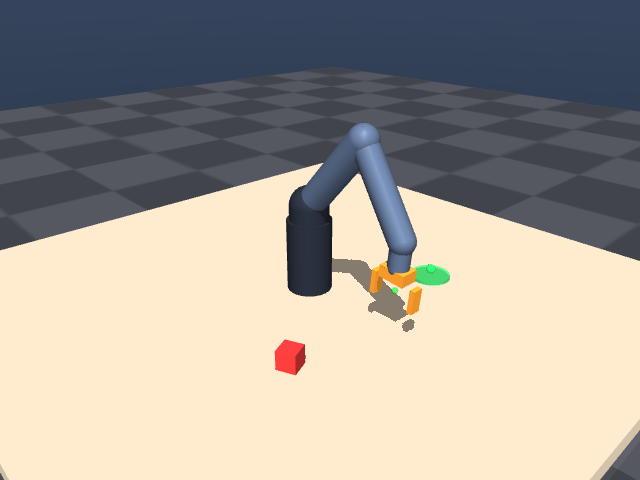

red cube = object to pick up   |   green disc = placement target


In [17]:
snap = render_scene_snapshot(cfg.env, cfg.reward, test_configs[0],
                             os.path.join(OUT, "plots", "scene_sample.png"),
                             camera="demo", width=cfg.video_width, height=cfg.video_height)
if snap:
    display(Image(filename=snap, width=560))
    print("red cube = object to pick up   |   green disc = placement target")
else:
    print("offscreen rendering unavailable in this runtime; training and evaluation are unaffected")

### 7.1 A rendered reference episode

The scripted IK controller, rendered. This is what a solved episode looks like — approach, grasp,
transport, release, placement — and it is the behaviour the agents have to discover on their own.

In [18]:
class _ScriptedPolicy:
    # Wraps the IK controller in the .predict() interface used by the evaluation code.
    def __init__(self, env, cfg): self.env, self.cfg = env, cfg
    def predict(self, obs, deterministic=True):
        e = self.env
        ec = e.episode_config
        z = self.cfg.env.table_height + self.cfg.env.object_half_size
        obj = np.array(list(ec.object_xy) + [z]); tgt = np.array(list(ec.target_xy) + [z])
        ee = e._ee_pos()
        if not e.ever_grasped:
            goal = obj + np.array([0, 0, 0.09]) if np.linalg.norm(ee[:2] - obj[:2]) > 0.02 else obj
            close = np.linalg.norm(ee - obj) < 0.04
        elif e.grasped:
            d = np.linalg.norm(e._obj_pos()[:2] - tgt[:2])
            goal = tgt + np.array([0, 0, 0.13]) if d > 0.015 else tgt + np.array([0, 0, 0.03])
            close = not (d < 0.015 and ee[2] < tgt[2] + 0.06)
        else:
            goal, close = ee + np.array([0, 0, 0.05]), False
        return ik_controller_action(e, goal, close), None

_renv = ArmPickPlaceEnv(cfg.env, cfg.reward, render_mode="rgb_array", camera="demo",
           width=cfg.video_width, height=cfg.video_height)
_frames = []
try:
    for ec in test_configs[:2]:
        f = []
        rollout_episode(_ScriptedPolicy(_renv, cfg), _renv, ec, render=True, frames=f)
        _frames += f + [f[-1]] * 25
    import imageio.v2 as imageio
    ref_path = os.path.join(OUT, "videos", "reference_scripted.mp4")
    os.makedirs(os.path.dirname(ref_path), exist_ok=True)
    imageio.mimwrite(ref_path, [np.asarray(x) for x in _frames], fps=cfg.video_fps,
                     macro_block_size=1, quality=8)
    display(show_video(ref_path))
except Exception as e:
    print("reference rendering skipped:", e)
finally:
    _renv.close()

---
## 8. Fair-benchmarking checklist

Before training, an explicit statement of what is held constant. Every one of these is enforced by
construction in the code above, not by convention.

| held constant | how |
|---|---|
| environment | one `ArmPickPlaceEnv` class, one MJCF model |
| observation space | fixed analytic normalisation inside the env — **no** `VecNormalize` for PPO only |
| action space | identical `Box(-1, 1, (5,))` incremental position control |
| reward function | one `RewardConfig`, shared |
| task difficulty | identical randomisation ranges |
| interaction budget | identical `total_timesteps`; PPO rounded **down** to whole rollouts |
| network | `[256, 256]` MLP everywhere |
| learning rate, γ | 3e-4, 0.98 everywhere |
| evaluation | the same `evaluate_on_configs` on the same fixed configuration sets |
| seeds | the same seed list for every algorithm |

The parameters that *do* differ are the ones intrinsic to each algorithm family — PPO's clip range
and epochs, SAC's entropy temperature, TD3's policy delay and exploration noise.

In [19]:
algo_cfgs = default_algo_configs()
rows = []
for a in cfg.algorithms:
    k = dict(algo_cfgs[a].kwargs)
    k.pop("policy_kwargs", None)
    rows.append({"algorithm": a, "n_envs": algo_cfgs[a].n_envs,
                 "hyper-parameters": ", ".join(f"{x}={y}" for x, y in k.items())})
display(pd.DataFrame(rows))
save_json({a: {"n_envs": algo_cfgs[a].n_envs,
               "kwargs": {k: str(v) for k, v in algo_cfgs[a].kwargs.items()}}
           for a in cfg.algorithms}, OUT, "configs", "algorithm_hyperparameters")

,algorithm,n_envs,hyper-parameters
0,PPO,8,"policy=MlpPolicy, learning_rate=0.0003, n_step..."
1,SAC,1,"policy=MlpPolicy, learning_rate=0.0003, buffer..."
2,TD3,1,"policy=MlpPolicy, learning_rate=0.0003, buffer..."


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


'outputs/arm_benchmark/configs/algorithm_hyperparameters.json'

### 8.1 Optional: a validation-only hyper-parameter mini-sweep

Disabled by default because it multiplies the compute. When enabled it trains a small number of
candidate settings at a reduced budget, scores them on **validation** configurations only, and
prints the winner. Test configurations are not involved at any point.

In [20]:
RUN_HPARAM_SEARCH = False   # set True if you have compute to spare

if RUN_HPARAM_SEARCH:
    search_budget = max(10_000, cfg.total_timesteps // 5)
    candidates = {
        "SAC_lr3e-4": dict(learning_rate=3e-4),
        "SAC_lr1e-3": dict(learning_rate=1e-3),
        "SAC_gamma0.95": dict(gamma=0.95),
    }
    hp_rows = []
    for name, over in candidates.items():
        base = default_algo_configs()["SAC"]
        trial = dict(cfg.algo_overrides)
        trial["SAC"] = AlgoConfig("SAC", base.n_envs, {**base.kwargs, **over})
        cfg.algo_overrides = trial
        rec = train_one("SAC", cfg.seeds[0], cfg, val_train, OUT,
                        total_timesteps=search_budget, tag=f"hp-{name}",
                        device=DEVICE, verbose=0)
        pol = load_model("SAC", rec["best_model"], device=DEVICE)
        r = evaluate_on_configs(pol, val_full, env_cfg=cfg.env, reward_cfg=cfg.reward)
        hp_rows.append({"candidate": name, "val_success": r["success"], "val_reward": r["reward"]})
    cfg.algo_overrides = {}
    hp = pd.DataFrame(hp_rows).sort_values("val_success", ascending=False)
    display(hp); save_table(hp, OUT, "hparam_search_validation")
else:
    print("hyper-parameter search skipped; using the documented literature-standard settings.\n"
          "This is stated as a limitation in the README: a tuned PPO could beat an untuned SAC.")

hyper-parameter search skipped; using the documented literature-standard settings.
This is stated as a limitation in the README: a tuned PPO could beat an untuned SAC.


---
## 9. Train PPO

On-policy. Collects a rollout with the current stochastic policy, then takes several epochs of
minibatch updates on a clipped surrogate objective so no update moves the policy too far from the
one that generated the data. It discards its data after each update, which makes it
sample-inefficient but very stable.

Every `eval_freq` environment steps a callback evaluates the current policy on **validation**
configurations, appends a row to the learning curve, and keeps the best checkpoint.

In [21]:
records = []
t0 = time.time()
for seed in cfg.seeds:
    records.append(train_one("PPO", seed, cfg, val_train, OUT, device=DEVICE, verbose=1))
print(f"PPO total wall time: {(time.time()-t0)/60:.1f} min")

  -> training PPO seed=0 for 49,152 env steps


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


    [val] step=   5000 success=0.00 reward=-127.4 grasp=0.00 d_obj_tgt=0.278
    [val] step=  10000 success=0.00 reward=-118.0 grasp=0.00 d_obj_tgt=0.278
    [val] step=  15000 success=0.00 reward=-116.4 grasp=0.00 d_obj_tgt=0.278
    [val] step=  20000 success=0.00 reward=-118.5 grasp=0.00 d_obj_tgt=0.278
    [val] step=  25000 success=0.00 reward=-106.2 grasp=0.00 d_obj_tgt=0.278
    [val] step=  30000 success=0.00 reward=-109.8 grasp=0.00 d_obj_tgt=0.278
    [val] step=  35000 success=0.00 reward=-104.6 grasp=0.00 d_obj_tgt=0.278
    [val] step=  40000 success=0.00 reward=-100.7 grasp=0.00 d_obj_tgt=0.278
    [val] step=  45000 success=0.00 reward=-110.5 grasp=0.12 d_obj_tgt=0.327
    [val] step=  49152 success=0.00 reward=-86.7 grasp=0.12 d_obj_tgt=0.254
     done in 0.9 min | best val success = 0.00
  -> training PPO seed=1 for 49,152 env steps
    [val] step=   5000 success=0.00 reward=-122.9 grasp=0.00 d_obj_tgt=0.278
    [val] step=  10000 success=0.00 reward=-121.4 grasp=0.00 

---
## 10. Train SAC

Off-policy and stochastic. Maximises reward *plus* policy entropy with an automatically tuned
temperature, and uses twin Q-functions to limit value overestimation. Replaying a buffer lets it
extract far more from each environment step than PPO, and the entropy term gives it structured
exploration.

In [22]:
t0 = time.time()
for seed in cfg.seeds:
    records.append(train_one("SAC", seed, cfg, val_train, OUT, device=DEVICE, verbose=1))
print(f"SAC total wall time: {(time.time()-t0)/60:.1f} min")

  -> training SAC seed=0 for 50,000 env steps
    [val] step=   5000 success=0.00 reward=-117.8 grasp=0.00 d_obj_tgt=0.278
    [val] step=  10000 success=0.00 reward=-126.2 grasp=0.62 d_obj_tgt=0.444
    [val] step=  15000 success=0.00 reward=-98.3 grasp=0.00 d_obj_tgt=0.278
    [val] step=  20000 success=0.00 reward=-102.6 grasp=0.00 d_obj_tgt=0.278
    [val] step=  25000 success=0.00 reward=-62.9 grasp=0.75 d_obj_tgt=0.172
    [val] step=  30000 success=0.12 reward=-67.7 grasp=0.50 d_obj_tgt=0.150
    [val] step=  35000 success=0.25 reward=102.8 grasp=0.50 d_obj_tgt=0.169
    [val] step=  40000 success=0.62 reward=199.0 grasp=1.00 d_obj_tgt=0.046
    [val] step=  45000 success=0.75 reward=120.7 grasp=1.00 d_obj_tgt=0.045
    [val] step=  50000 success=0.62 reward=152.7 grasp=0.88 d_obj_tgt=0.076
     done in 10.0 min | best val success = 0.75
  -> training SAC seed=1 for 50,000 env steps
    [val] step=   5000 success=0.00 reward=-108.7 grasp=0.00 d_obj_tgt=0.278
    [val] step=  100

---
## 11. Train TD3

Off-policy and deterministic. Twin critics with a clipped double-Q target, policy updates delayed
to every second critic update, and target-policy smoothing. Exploration comes from Gaussian action
noise rather than an entropy bonus, which makes TD3 more sensitive to the noise scale on a task
whose reward landscape changes shape the moment the cube is grasped.

In [23]:
t0 = time.time()
for seed in cfg.seeds:
    records.append(train_one("TD3", seed, cfg, val_train, OUT, device=DEVICE, verbose=1))
print(f"TD3 total wall time: {(time.time()-t0)/60:.1f} min")

save_json(records, OUT, "metrics", "training_records")
display(pd.DataFrame(records)[["algo", "seed", "total_timesteps", "wall_time_s",
                               "best_val_success"]])

  -> training TD3 seed=0 for 50,000 env steps
    [val] step=   5000 success=0.00 reward=-141.5 grasp=0.00 d_obj_tgt=0.278
    [val] step=  10000 success=0.00 reward=-121.4 grasp=0.25 d_obj_tgt=0.331
    [val] step=  15000 success=0.00 reward=-101.5 grasp=0.38 d_obj_tgt=0.279
    [val] step=  20000 success=0.00 reward=-111.0 grasp=0.38 d_obj_tgt=0.354
    [val] step=  25000 success=0.00 reward=-99.4 grasp=0.25 d_obj_tgt=0.282
    [val] step=  30000 success=0.00 reward=-90.0 grasp=0.38 d_obj_tgt=0.234
    [val] step=  35000 success=0.00 reward=-84.5 grasp=0.38 d_obj_tgt=0.214
    [val] step=  40000 success=0.00 reward=-97.3 grasp=0.12 d_obj_tgt=0.269
    [val] step=  45000 success=0.00 reward=-117.2 grasp=0.25 d_obj_tgt=0.339
    [val] step=  50000 success=0.00 reward=-96.9 grasp=0.12 d_obj_tgt=0.252
     done in 5.9 min | best val success = 0.00
  -> training TD3 seed=1 for 50,000 env steps
    [val] step=   5000 success=0.00 reward=-141.1 grasp=0.00 d_obj_tgt=0.366
    [val] step=  10

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,algo,seed,total_timesteps,wall_time_s,best_val_success
0,PPO,0,49152,52.2,0.000
1,PPO,1,49152,53.4,0.000
2,SAC,0,50000,597.0,0.750
3,SAC,1,50000,599.2,0.500
4,TD3,0,50000,352.7,0.000
5,TD3,1,50000,357.7,0.125


---
## 12. Validation evaluation

Each run's best checkpoint is reloaded **from disk** — which also demonstrates that models save and
reload correctly, and that evaluation is entirely independent of training — and evaluated on the
full validation set.

In [24]:
policies, val_results = {}, {}
for algo in cfg.algorithms:
    policies[algo], val_results[algo] = [], []
    for rec in [r for r in records if r["algo"] == algo]:
        pol = load_model(algo, rec["best_model"], device=DEVICE)     # reload from disk
        policies[algo].append(pol)
        res = evaluate_on_configs(pol, val_full, env_cfg=cfg.env, reward_cfg=cfg.reward)
        val_results[algo].append(res)
        write_episode_csv(os.path.join(OUT, "metrics",
                                       f"val_episodes_{algo}_seed{rec['seed']}.csv"),
                          res["episodes"])
        print(f"{algo} seed {rec['seed']}: val success {res['success']:.2f}  "
              f"reward {res['reward']:7.1f}  grasp {res['grasp_success']:.2f}  "
              f"final dist {res['final_obj_target_dist']:.3f} m")

val_table = aggregate_metric_table(val_results,
                                   ["success", "grasp_success", "place_success", "reward",
                                    "ep_len", "final_obj_target_dist", "collision_rate",
                                    "action_magnitude"])
display(val_table); save_table(val_table, OUT, "validation_metrics")

PPO seed 0: val success 0.00  reward   -89.8  grasp 0.20  final dist 0.270 m
PPO seed 1: val success 0.00  reward   -96.0  grasp 0.10  final dist 0.285 m
SAC seed 0: val success 0.60  reward   285.0  grasp 0.95  final dist 0.055 m
SAC seed 1: val success 0.30  reward   114.2  grasp 0.95  final dist 0.096 m
TD3 seed 0: val success 0.00  reward   -87.6  grasp 0.45  final dist 0.225 m
TD3 seed 1: val success 0.10  reward   -78.7  grasp 0.45  final dist 0.218 m


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Algorithm,seeds,success,grasp_success,place_success,reward,ep_len,final_obj_target_dist,collision_rate,action_magnitude
0,PPO,2,0.000 ± 0.000,0.150 ± 0.071,0.000 ± 0.000,-92.863 ± 4.379,200.000 ± 0.000,0.277 ± 0.011,0.074 ± 0.037,0.111 ± 0.020
1,SAC,2,0.450 ± 0.212,0.950 ± 0.000,0.900 ± 0.071,199.600 ± 120.746,137.725 ± 33.199,0.075 ± 0.029,0.152 ± 0.158,0.511 ± 0.121
2,TD3,2,0.050 ± 0.071,0.450 ± 0.000,0.050 ± 0.071,-83.170 ± 6.334,195.550 ± 6.293,0.222 ± 0.005,0.099 ± 0.007,0.292 ± 0.012


'outputs/arm_benchmark/metrics/validation_metrics.csv'

---
## 13. Compare the algorithms — learning curves and sample efficiency

Sample efficiency is the point of this benchmark, so everything is plotted against **environment
interaction steps**. Two derived numbers:

* **steps to threshold** — the first step count at which validation success reaches 50 %, linearly
  interpolated between evaluations; `inf` when a seed never gets there.
* **stability** — the standard deviation of validation success over the last 40 % of training.
  Lower is better; it captures the late-training oscillation that actually makes checkpoint
  selection hard.

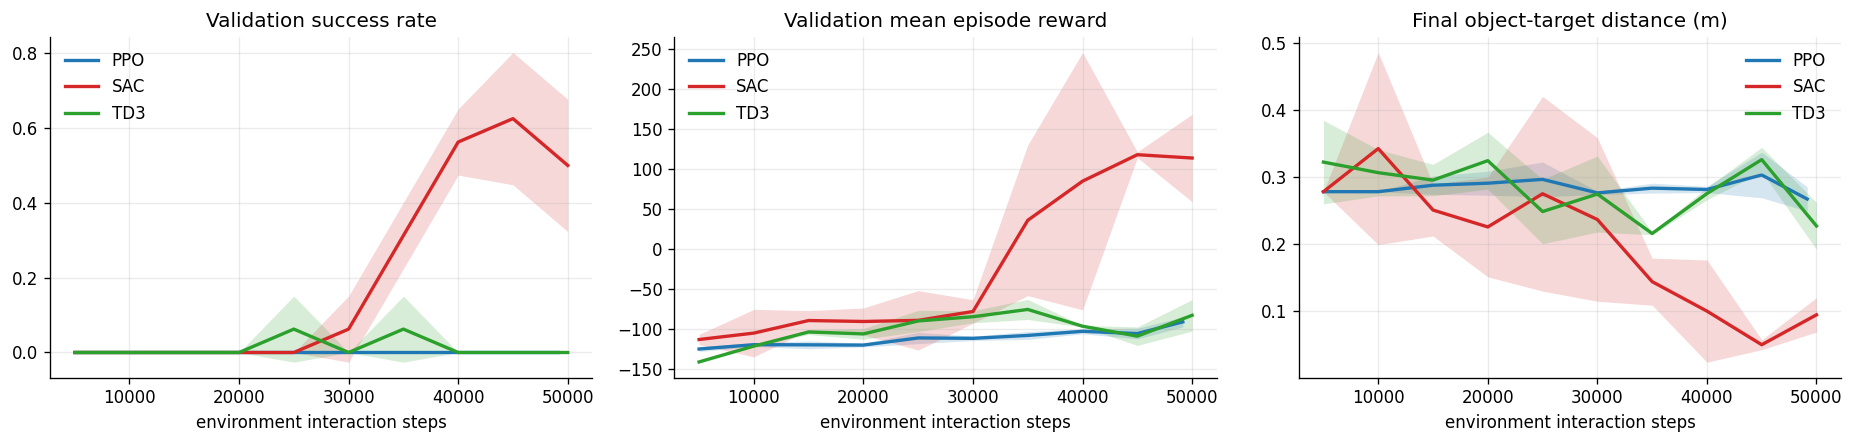

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


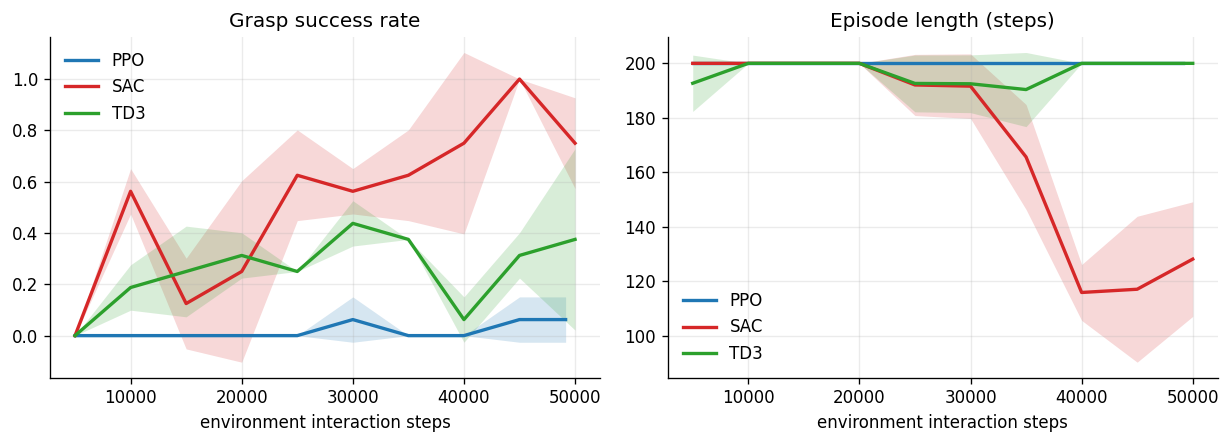

,algo,seed,steps_to_threshold,stability,final_val_success,best_val_success
0,PPO,0,inf,0.000000,0.000,0.000
1,PPO,1,inf,0.000000,0.000,0.000
2,SAC,0,3.833333e+04,0.187500,0.625,0.750
3,SAC,1,4.000000e+04,0.062500,0.375,0.500
4,TD3,0,inf,0.000000,0.000,0.000
5,TD3,1,inf,0.054127,0.000,0.125


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


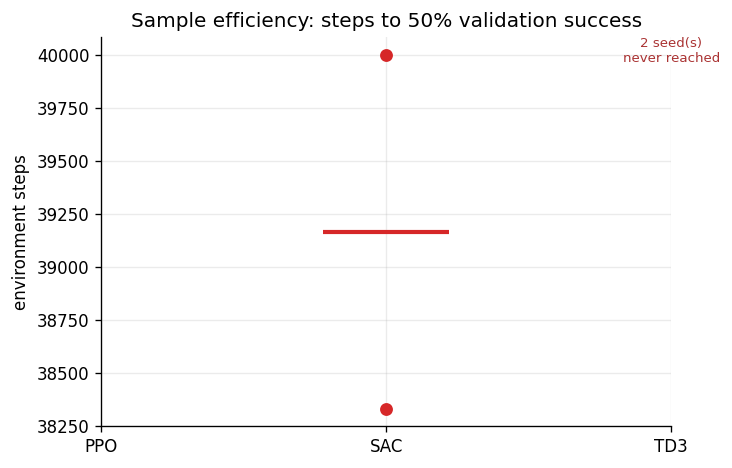

In [25]:
curves = load_curves(records)
curves.to_csv(os.path.join(OUT, "metrics", "learning_curves.csv"), index=False)
THR = cfg.success_threshold_for_sample_efficiency

p1 = plot_learning_curves(curves, OUT,
                                metrics=("success", "reward", "final_obj_target_dist"))
p2 = plot_learning_curves(curves, OUT, metrics=("grasp_success", "ep_len"),
                                name="learning_curves_secondary")
display(Image(filename=p1)); display(Image(filename=p2))

eff = sample_efficiency_table(curves, THR)
display(eff); save_table(eff, OUT, "sample_efficiency")
display(Image(filename=plot_sample_efficiency(eff, OUT, THR)))

---
## 14. Select the best algorithm and checkpoint — **on validation only**

The winner is the algorithm with the highest mean validation success across seeds, with mean
validation reward as the tie-break. The seed used for the demonstration video is picked the same
way. **The test set has not been read at this point.**

In [26]:
best_algo, selection_df = select_best_algorithm(val_results)
best_seed = select_best_seed(val_results[best_algo], cfg.seeds)
display(selection_df); save_table(selection_df, OUT, "model_selection_validation")
display(Markdown(f"### Selected on validation: **{best_algo}** (demonstration seed {best_seed})"))

,algo,val_success_mean,val_success_std,val_reward_mean,n_seeds
0,SAC,0.45,0.212132,199.600190,2
1,TD3,0.05,0.070711,-83.169624,2
2,PPO,0.00,0.000000,-92.862630,2


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### Selected on validation: **SAC** (demonstration seed 0)

---
## 15. Freeze the configuration

From here nothing is tuned. The selected algorithm, its hyper-parameters, the environment
configuration and the checkpoint choice are written to `configs/frozen_configuration.json`, and
only then does the test set get touched.

In [27]:
frozen = {
    "selected_algorithm": best_algo,
    "selected_demo_seed": best_seed,
    "selection_basis": "mean validation success across seeds; validation reward as tie-break",
    "test_set_used_for_selection": False,
    "frozen_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    "experiment_config": cfg.as_dict(),
    "checkpoints": {a: [r["best_model"] for r in records if r["algo"] == a]
                    for a in cfg.algorithms},
}
path = save_json(frozen, OUT, "configs", "frozen_configuration")
print("configuration frozen ->", path)
print("no further tuning happens below this line.")

configuration frozen -> outputs/arm_benchmark/configs/frozen_configuration.json
no further tuning happens below this line.


---
## 16. Final evaluation on the untouched test environments

The held-out configurations are read for the first time. All three algorithms are reported — the
table needs them — but the *winner was already chosen* in section 14 from validation alone. The
test set measures generalisation to configurations no agent trained on and no decision was based
on.

PPO seed 0: TEST success 0.00 [0.00, 0.11] over 30 episodes | reward  -103.1 | grasp 0.20
PPO seed 1: TEST success 0.00 [0.00, 0.11] over 30 episodes | reward   -99.8 | grasp 0.00
SAC seed 0: TEST success 0.60 [0.42, 0.75] over 30 episodes | reward   186.6 | grasp 0.97
SAC seed 1: TEST success 0.20 [0.10, 0.37] over 30 episodes | reward   154.1 | grasp 0.87
TD3 seed 0: TEST success 0.00 [0.00, 0.11] over 30 episodes | reward  -103.7 | grasp 0.43
TD3 seed 1: TEST success 0.00 [0.00, 0.11] over 30 episodes | reward  -101.6 | grasp 0.50


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Algorithm,seeds,success,grasp_success,place_success,reward,ep_len,final_obj_target_dist,collision_rate,action_magnitude,object_lost
0,PPO,2,0.000 ± 0.000,0.100 ± 0.141,0.000 ± 0.000,-101.443 ± 2.298,198.633 ± 1.933,0.309 ± 0.016,0.076 ± 0.002,0.103 ± 0.005,0.017 ± 0.024
1,SAC,2,0.400 ± 0.283,0.917 ± 0.071,0.833 ± 0.189,170.350 ± 22.970,137.733 ± 39.834,0.107 ± 0.074,0.155 ± 0.143,0.498 ± 0.082,0.017 ± 0.024
2,TD3,2,0.000 ± 0.000,0.467 ± 0.047,0.000 ± 0.000,-102.652 ± 1.548,200.000 ± 0.000,0.277 ± 0.002,0.159 ± 0.000,0.314 ± 0.023,0.000 ± 0.000


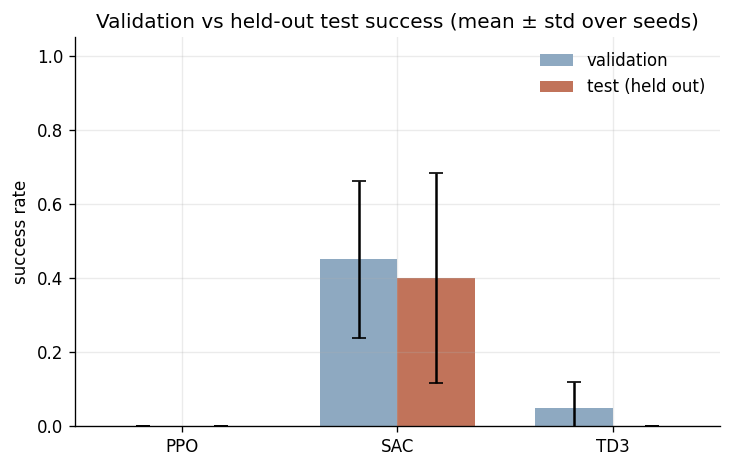

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [28]:
test_results = {}
for algo in cfg.algorithms:
    test_results[algo] = []
    for seed, pol in zip(cfg.seeds, policies[algo]):
        res = evaluate_on_configs(pol, test_configs, env_cfg=cfg.env, reward_cfg=cfg.reward)
        test_results[algo].append(res)
        write_episode_csv(os.path.join(OUT, "metrics",
                                       f"test_episodes_{algo}_seed{seed}.csv"), res["episodes"])
        lo, hi = binomial_ci(res["n_success"], res["n_episodes"])
        print(f"{algo} seed {seed}: TEST success {res['success']:.2f} "
              f"[{lo:.2f}, {hi:.2f}] over {res['n_episodes']} episodes | "
              f"reward {res['reward']:7.1f} | grasp {res['grasp_success']:.2f}")

test_table = aggregate_metric_table(test_results,
                                    ["success", "grasp_success", "place_success", "reward",
                                     "ep_len", "final_obj_target_dist", "collision_rate",
                                     "action_magnitude", "object_lost"])
display(test_table); save_table(test_table, OUT, "test_metrics")
display(Image(filename=plot_val_vs_test(
    [{"algo": a,
      "val_mean": mean_std_ci([r["success"] for r in val_results[a]])["mean"],
      "val_std":  mean_std_ci([r["success"] for r in val_results[a]])["std"],
      "test_mean": mean_std_ci([r["success"] for r in test_results[a]])["mean"],
      "test_std":  mean_std_ci([r["success"] for r in test_results[a]])["std"]}
     for a in cfg.algorithms], OUT)))

### 16.1 Statistical comparison

Welch's t-test on the per-seed test success rates of the top two algorithms, plus Cohen's *d*. With
3–5 seeds this test is **underpowered**: only very large effects are detectable, and a non-significant
p-value here is not evidence of equivalence. The result is reported with that caveat attached rather
than dressed up as significance.

In [29]:
ranked = sorted(cfg.algorithms,
                key=lambda a: -mean_std_ci([r["success"] for r in test_results[a]])["mean"])
stat = welch_ttest([r["success"] for r in test_results[ranked[0]]],
                   [r["success"] for r in test_results[ranked[1]]])
print(f"{ranked[0]} vs {ranked[1]} on held-out test success (per-seed samples):")
for k, v in stat.items():
    print(f"  {k:>10}: {v}")
save_json({"comparison": f"{ranked[0]} vs {ranked[1]}", **stat}, OUT, "metrics",
          "significance_test")
if len(cfg.seeds) < 3:
    print("\nNOTE: fewer than 3 seeds -- no statistical claim is made at this preset.")

SAC vs PPO on held-out test success (per-seed samples):
         n_a: 2
         n_b: 2
      mean_a: 0.4
      mean_b: 0.0
           t: 2.0000000000000004
           p: 0.2951672353008664
    cohens_d: 2.0000000000000004
        note: underpowered: with 2 vs 2 seeds only very large effects are detectable

NOTE: fewer than 3 seeds -- no statistical claim is made at this preset.


---
## 17. Generalisation experiment

Every algorithm's policies are evaluated on five configuration distributions. The first is the
training distribution and acts as the reference; the other four shift it in ways that are
meaningful but still physically reasonable.

| suite | shift |
|---|---|
| `in_distribution` | none — the reference point |
| `unseen_sectors` | cube and target in an azimuth sector (1.05–1.55 rad) never sampled in training |
| `far_targets` | target radius 0.41–0.50 m, beyond the training range → longer transport |
| `hard_initial_pose` | initial joint noise tripled to 0.45 rad |
| `heavy_object` | cube 2–4× heavier than anything seen in training |

Reporting the *degradation* relative to `in_distribution` separates "the policy learned the task"
from "the policy memorised a region of the workspace".

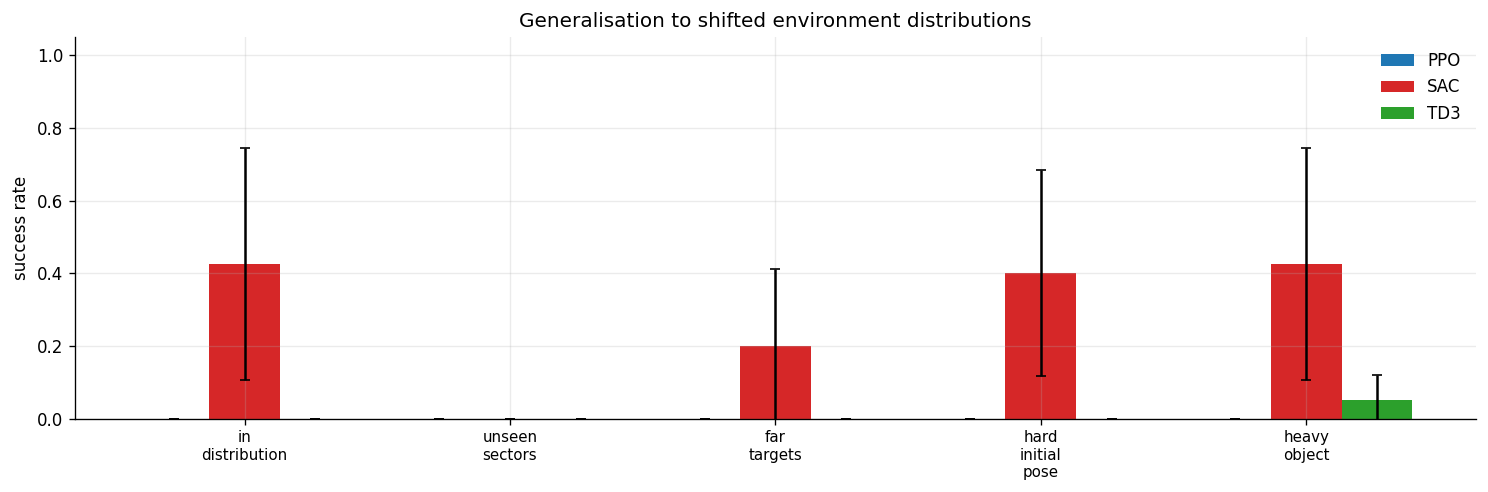

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Algorithm,Suite,Success,Δ vs in-distribution
0,PPO,in_distribution,0.00 ± 0.00,—
1,PPO,unseen_sectors,0.00 ± 0.00,+0.00
2,PPO,far_targets,0.00 ± 0.00,+0.00
3,PPO,hard_initial_pose,0.00 ± 0.00,+0.00
4,PPO,heavy_object,0.00 ± 0.00,+0.00
5,SAC,in_distribution,0.43 ± 0.32,—
6,SAC,unseen_sectors,0.00 ± 0.00,-0.43
7,SAC,far_targets,0.20 ± 0.21,-0.23
8,SAC,hard_initial_pose,0.40 ± 0.28,-0.03
9,SAC,heavy_object,0.43 ± 0.32,+0.00


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [30]:
if cfg.run_generalization:
    gen, gen_df = run_generalization(policies, cfg, OUT)
    gen_df.to_csv(os.path.join(OUT, "metrics", "generalization.csv"), index=False)
    display(Image(filename=plot_generalization(gen, OUT)))

    rows = []
    for algo, d in gen.items():
        base = d["in_distribution"]["mean"]
        for suite, s in d.items():
            rows.append({"Algorithm": algo, "Suite": suite,
                         "Success": f"{s['mean']:.2f} ± {s['std']:.2f}",
                         "Δ vs in-distribution":
                             "—" if suite == "in_distribution"
                             else f"{s['mean'] - base:+.2f}"})
    gtab = pd.DataFrame(rows)
    display(gtab); save_table(gtab, OUT, "generalization_table")
else:
    print("generalisation experiment disabled in this preset")

---
## 18. Robustness experiment

For the **selected** algorithm only, four single-factor sweeps: object mass, target distance band,
initial-pose spread and observation noise. Each point is a fresh set of held-out configurations
evaluated with every seed's policy.

These are stress tests, deliberately reported separately from the primary test benchmark in
section 16. They describe how the selected policy degrades as conditions get harder; they are not
the headline result.

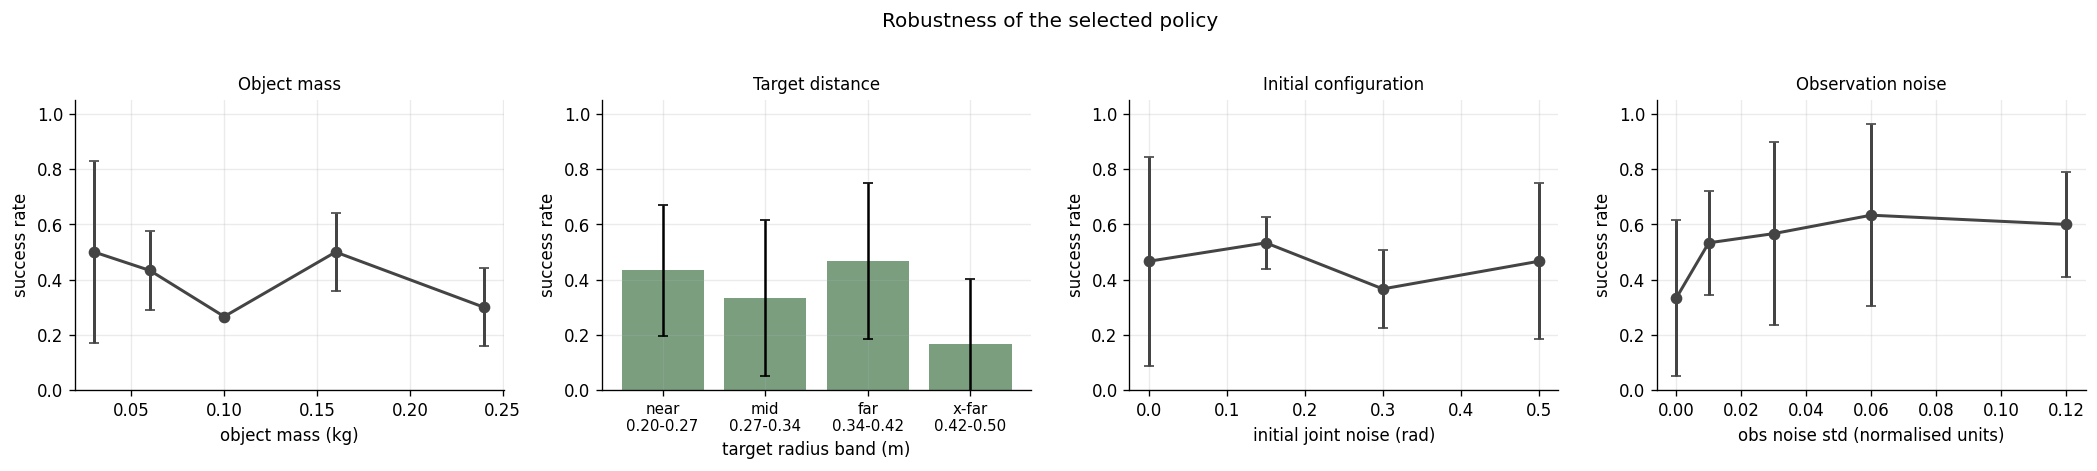

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,factor,value,mean,std
0,initial_pose,0.0,0.467,0.377
1,initial_pose,0.15,0.533,0.094
2,initial_pose,0.3,0.367,0.141
3,initial_pose,0.5,0.467,0.283
4,object_mass,0.03,0.500,0.330
5,object_mass,0.06,0.433,0.141
6,object_mass,0.1,0.267,0.000
7,object_mass,0.16,0.500,0.141
8,object_mass,0.24,0.300,0.141
9,observation_noise,0.0,0.333,0.283


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [31]:
if cfg.run_robustness:
    rob, rob_df = run_robustness(policies[best_algo], cfg, OUT)
    rob_df.to_csv(os.path.join(OUT, "metrics", "robustness.csv"), index=False)
    display(Image(filename=plot_robustness(rob, OUT)))
    display(rob_df.groupby(["factor", "value"])["success"]
            .agg(["mean", "std"]).round(3).reset_index())
else:
    print("robustness experiment disabled in this preset")

---
## 19. Ablation study

**Observation ablation** (the primary one). The selected algorithm is retrained at a reduced budget
with three observation designs:

* `joint_only` (9-D) — proprioception only. The cube and target are invisible, so the task is
  genuinely unobservable and this arm is a *floor* for the benchmark.
* `joint_ee` (16-D) — proprioception plus end-effector state. Still no task information.
* `full` (31-D) — the task-aware observation used throughout the benchmark.

This isolates how much of the reported performance comes from the observation design rather than
from the algorithm.

**Reward ablation** (enabled in the `standard` and `full` presets). Retrain with the grasp bonus,
the transport term or the reach term removed. Training uses the modified reward; evaluation always
uses the full reward, so the numbers remain comparable.

  -> training SAC seed=0 for 25,000 env steps
    [val] step=   5000 success=0.00 reward=-139.1 grasp=0.00 d_obj_tgt=0.278
    [val] step=  10000 success=0.00 reward=-126.3 grasp=0.00 d_obj_tgt=0.278
    [val] step=  15000 success=0.00 reward=-111.9 grasp=0.25 d_obj_tgt=0.284
    [val] step=  20000 success=0.00 reward=-109.9 grasp=0.00 d_obj_tgt=0.278
    [val] step=  25000 success=0.00 reward=-119.5 grasp=0.00 d_obj_tgt=0.278
     done in 4.8 min | best val success = 0.00
  -> training SAC seed=0 for 25,000 env steps
    [val] step=   5000 success=0.00 reward=-111.5 grasp=0.00 d_obj_tgt=0.278
    [val] step=  10000 success=0.00 reward=-128.9 grasp=0.00 d_obj_tgt=0.278
    [val] step=  15000 success=0.00 reward=-123.0 grasp=0.25 d_obj_tgt=0.311
    [val] step=  20000 success=0.00 reward=-123.6 grasp=0.12 d_obj_tgt=0.322
    [val] step=  25000 success=0.00 reward=-157.7 grasp=0.00 d_obj_tgt=0.278
     done in 4.9 min | best val success = 0.00
  -> training SAC seed=0 for 25,000 env step

success     grasp_success       reward    
              mean std          mean std     mean std
obs_mode                                             
full           0.0 NaN          0.75 NaN  -62.880 NaN
joint_ee       0.0 NaN          0.00 NaN -111.534 NaN
joint_only     0.0 NaN          0.00 NaN -109.942 NaN

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


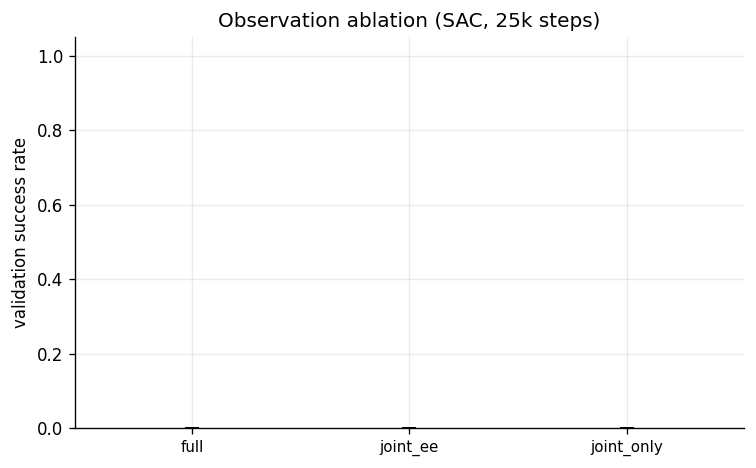

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [32]:
if cfg.run_ablation:
    val_by_mode = {m: make_config_set(cfg.n_val_configs_during_training,
                                      cfg.val_config_seed, cfg.env, tag="val")
                   for m in cfg.ablation_obs_modes}
    abl = run_observation_ablation(best_algo, cfg, val_by_mode, OUT, train_one, load_model,
                                   device=DEVICE, verbose=1)
    abl.to_csv(os.path.join(OUT, "metrics", "ablation_observation.csv"), index=False)
    display(abl.groupby("obs_mode")[["success", "grasp_success", "reward"]]
            .agg(["mean", "std"]).round(3))
    display(Image(filename=plot_ablation(
        abl, OUT, "obs_mode",
        f"Observation ablation ({best_algo}, {cfg.ablation_timesteps//1000}k steps)",
        "ablation_observation")))
else:
    print("observation ablation disabled in this preset")

In [33]:
if cfg.run_reward_ablation:
    rabl = run_reward_ablation(best_algo, cfg, val_full, OUT, train_one, load_model,
                               device=DEVICE, verbose=1)
    rabl.to_csv(os.path.join(OUT, "metrics", "ablation_reward.csv"), index=False)
    display(rabl.groupby("reward_variant")[["success", "grasp_success", "reward"]]
            .agg(["mean", "std"]).round(3))
    display(Image(filename=plot_ablation(
        rabl, OUT, "reward_variant", f"Reward ablation ({best_algo})", "ablation_reward")))
else:
    print("reward ablation disabled in this preset (enable it with cfg.run_reward_ablation = True)")

reward ablation disabled in this preset (enable it with cfg.run_reward_ablation = True)


---
## 20. Final benchmark table

Built entirely from the CSV and JSON artefacts written by the runs above. Nothing here is typed in
by hand.

In [34]:
bench = build_benchmark_table(val_results, test_results, eff, THR)
save_table(bench, OUT, "benchmark_table")
display(Markdown("### Final benchmark\n\n" + bench.to_markdown(index=False)))

### Final benchmark

| Algorithm   | Val Success   | Test Success   | Test Success 95% CI   | Mean Reward   |   Grasp Rate |   Final Dist (m) | Steps to 50% Val   |   Stability (val σ) |
|:------------|:--------------|:---------------|:----------------------|:--------------|-------------:|-----------------:|:-------------------|--------------------:|
| SAC         | 0.45 ± 0.21   | 0.40 ± 0.28    | [-2.14, 2.94]         | 170.4 ± 23.0  |         0.92 |            0.107 | 39k                |               0.125 |
| PPO         | 0.00 ± 0.00   | 0.00 ± 0.00    | [0.00, 0.00]          | -101.4 ± 2.3  |         0.1  |            0.309 | not reached        |               0     |
| TD3         | 0.05 ± 0.07   | 0.00 ± 0.00    | [0.00, 0.00]          | -102.7 ± 1.5  |         0.47 |            0.277 | not reached        |               0.027 |

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---
## 21. Render the final policy

Training never rendered a single frame. Now the selected policy is rolled out again on **held-out
test** configurations with the offscreen renderer. Successful episodes are preferred; if the policy
has not learned to succeed at this budget the notebook shows its actual behaviour rather than
hiding it.

In [35]:
demo_policy = policies[best_algo][list(cfg.seeds).index(best_seed)]
video_path = os.path.join(OUT, "videos", f"demo_{best_algo}_seed{best_seed}.mp4")

vid = record_episodes(demo_policy, test_configs, cfg.env, cfg.reward, video_path,
                      camera="demo", width=cfg.video_width, height=cfg.video_height,
                      fps=cfg.video_fps, max_episodes=cfg.n_demo_episodes,
                      only_successful=True)
if vid["video"] is None:
    print("no successful test episode at this budget -- showing unfiltered behaviour instead")
    vid = record_episodes(demo_policy, test_configs, cfg.env, cfg.reward, video_path,
                          camera="demo", width=cfg.video_width, height=cfg.video_height,
                          fps=cfg.video_fps, max_episodes=cfg.n_demo_episodes)
print(f"{best_algo} (seed {best_seed}) on held-out test configurations:")
for e in vid["episodes"]:
    print(f"  {e['uid']}: success={int(e['success'])} grasp={int(e['grasp_success'])} "
          f"return={e['reward']:.1f} len={int(e['ep_len'])} "
          f"final dist={e['final_obj_target_dist']:.3f} m")

SAC (seed 0) on held-out test configurations:
  test-0002: success=1 grasp=1 return=647.7 len=143 final dist=0.037 m
  test-0003: success=1 grasp=1 return=85.1 len=47 final dist=0.024 m


### 21.1 Robotic-arm demonstration

Approach → grasp → transport → release → placement.

In [36]:
display(show_video(vid["video"], width=640))

In [37]:
# a second camera angle, for the report
vid_top = record_episodes(demo_policy, test_configs, cfg.env, cfg.reward,
                          os.path.join(OUT, "videos", f"demo_{best_algo}_front.mp4"),
                          camera="front", width=cfg.video_width, height=cfg.video_height,
                          fps=cfg.video_fps, max_episodes=max(1, cfg.n_demo_episodes - 1),
                          only_successful=True)
display(show_video(vid_top["video"]) if vid_top["video"] else HTML("<i>skipped</i>"))

---
## 22. Save models and results

Everything is already on disk; this cell lists it and packages it into a single archive you can
download from Colab.

In [38]:
for dirpath, _, files in sorted(os.walk(OUT)):
    rel = os.path.relpath(dirpath, OUT)
    if not files:
        continue
    print(f"\n{rel}/")
    for fn in sorted(files)[:14]:
        size = os.path.getsize(os.path.join(dirpath, fn)) / 1024
        print(f"   {fn:<52} {size:8.1f} KB")
    if len(files) > 14:
        print(f"   ... and {len(files)-14} more")

import shutil
archive = shutil.make_archive(f"{cfg.run_name}_results", "zip", OUT)
print(f"\narchive: {archive} ({os.path.getsize(archive)/1e6:.1f} MB)")
try:
    from google.colab import files as colab_files
    print("run `colab_files.download(archive)` to download it")
except ImportError:
    pass


configs/
   algorithm_hyperparameters.json                            1.3 KB
   experiment_config.json                                    2.0 KB
   frozen_configuration.json                                 2.8 KB
   splits.json                                              21.6 KB

final_report/
   benchmark_table.md                                        0.8 KB
   generalization_table.md                                   1.3 KB
   model_selection_validation.md                             0.4 KB
   sample_efficiency.md                                      0.8 KB
   test_metrics.md                                           1.0 KB
   validation_metrics.md                                     0.9 KB

logs/ablObs-full_SAC_seed0/
   monitor_0.monitor.csv                                     3.4 KB

logs/ablObs-joint_ee_SAC_seed0/
   monitor_0.monitor.csv                                     3.4 KB

logs/ablObs-joint_only_SAC_seed0/
   monitor_0.monitor.csv                                     3

---
## 23. Final experiment summary

A concise, automatically generated report written from the measured results only.

In [39]:
def build_summary() -> str:
    lines = []
    A = lines.append
    A(f"# Benchmark summary — {cfg.run_name}")
    A("")
    A(f"* preset **{PRESET}** — {cfg.total_timesteps:,} environment steps per run, "
      f"{len(cfg.seeds)} seeds per algorithm "
      f"({len(cfg.algorithms)*len(cfg.seeds)*cfg.total_timesteps:,} total env steps)")
    A(f"* task: 4-DoF MuJoCo arm, reach → grasp → transport → place, "
      f"success = cube at rest within {cfg.env.success_threshold*100:.0f} cm of the target")
    A(f"* observation {cfg.env.obs_mode} | action Box(-1,1,(5,)) incremental joint position targets")
    A(f"* split: training configurations sampled online; {len(val_full)} validation and "
      f"{len(test_configs)} test configurations from disjoint seeds")
    A("")
    A("## Final benchmark")
    A("")
    A(bench.to_markdown(index=False))
    A("")
    A("## Model selection")
    A("")
    A(f"**{best_algo}** was selected on validation performance alone "
      f"(mean validation success across seeds, validation reward as tie-break). "
      f"The configuration was frozen before the test set was read.")
    A("")
    ts = {a: mean_std_ci([r['success'] for r in test_results[a]]) for a in cfg.algorithms}
    A("## Held-out test performance")
    A("")
    for a in sorted(ts, key=lambda x: -ts[x]["mean"]):
        s = ts[a]
        A(f"* **{a}**: {s['mean']:.2f} ± {s['std']:.2f} success "
          f"(95% CI on the mean over seeds: [{s['ci_low']:.2f}, {s['ci_high']:.2f}], n={s['n']})")
    A("")
    A(f"Welch's t-test, {ranked[0]} vs {ranked[1]}: "
      f"t={stat.get('t', float('nan')):.3f}, p={stat.get('p', float('nan')):.3f}. "
      f"{stat.get('note','')}")
    A("")
    A("## Sample efficiency")
    A("")
    for a in cfg.algorithms:
        v = eff[eff["algo"] == a]["steps_to_threshold"].to_numpy(float)
        fin = v[np.isfinite(v)]
        A(f"* **{a}**: reached {THR:.0%} validation success in "
          + (f"{np.mean(fin)/1000:.0f}k steps ({len(fin)}/{len(v)} seeds)" if len(fin)
             else f"no seed reached it within {cfg.total_timesteps:,} steps"))
    A("")
    if cfg.run_generalization:
        A("## Generalisation")
        A("")
        for a in gen:
            base = gen[a]["in_distribution"]["mean"]
            worst = min(((s, d["mean"]) for s, d in gen[a].items() if s != "in_distribution"),
                        key=lambda kv: kv[1])
            A(f"* **{a}**: {base:.2f} in-distribution → {worst[1]:.2f} on `{worst[0]}` "
              f"({worst[1]-base:+.2f})")
        A("")
    if cfg.run_robustness:
        A("## Robustness of the selected policy")
        A("")
        for f, d in rob.items():
            A(f"* **{d['title']}**: success {d['success'][0]:.2f} at `{d['x'][0]}` → "
              f"{d['success'][-1]:.2f} at `{d['x'][-1]}`")
        A("")
    if cfg.run_ablation:
        A("## Observation ablation")
        A("")
        g = abl.groupby("obs_mode")["success"].mean()
        for m in cfg.ablation_obs_modes:
            if m in g.index:
                A(f"* `{m}`: {g[m]:.2f} validation success at "
                  f"{cfg.ablation_timesteps:,} steps")
        A("")
    A("## Limitations")
    A("")
    A("* Simulation only; no hardware evaluation.")
    A("* Grasping is kinematically abstracted — see the README for why and for what it costs.")
    A(f"* {len(cfg.seeds)} seeds and {cfg.total_timesteps:,} steps per run: confidence intervals "
      "are wide and the significance test is underpowered.")
    A("* Literature-standard hyper-parameters rather than a per-algorithm sweep; a tuned PPO "
      "could beat an untuned SAC.")
    A("* Rankings at this budget need not hold at millions of steps — PPO in particular is known "
      "to close ground with far more data.")
    return "\n".join(lines)

summary = build_summary()
path = os.path.join(OUT, "final_report", "summary.md")
os.makedirs(os.path.dirname(path), exist_ok=True)
with open(path, "w") as f:
    f.write(summary)
display(Markdown(summary))
print("\nwritten to", path)

# Benchmark summary — arm_benchmark

* preset **quick** — 50,000 environment steps per run, 2 seeds per algorithm (300,000 total env steps)
* task: 4-DoF MuJoCo arm, reach → grasp → transport → place, success = cube at rest within 5 cm of the target
* observation full | action Box(-1,1,(5,)) incremental joint position targets
* split: training configurations sampled online; 20 validation and 30 test configurations from disjoint seeds

## Final benchmark

| Algorithm   | Val Success   | Test Success   | Test Success 95% CI   | Mean Reward   |   Grasp Rate |   Final Dist (m) | Steps to 50% Val   |   Stability (val σ) |
|:------------|:--------------|:---------------|:----------------------|:--------------|-------------:|-----------------:|:-------------------|--------------------:|
| SAC         | 0.45 ± 0.21   | 0.40 ± 0.28    | [-2.14, 2.94]         | 170.4 ± 23.0  |         0.92 |            0.107 | 39k                |               0.125 |
| PPO         | 0.00 ± 0.00   | 0.00 ± 0.00    | [0.00, 0.00]          | -101.4 ± 2.3  |         0.1  |            0.309 | not reached        |               0     |
| TD3         | 0.05 ± 0.07   | 0.00 ± 0.00    | [0.00, 0.00]          | -102.7 ± 1.5  |         0.47 |            0.277 | not reached        |               0.027 |

## Model selection

**SAC** was selected on validation performance alone (mean validation success across seeds, validation reward as tie-break). The configuration was frozen before the test set was read.

## Held-out test performance

* **SAC**: 0.40 ± 0.28 success (95% CI on the mean over seeds: [-2.14, 2.94], n=2)
* **PPO**: 0.00 ± 0.00 success (95% CI on the mean over seeds: [0.00, 0.00], n=2)
* **TD3**: 0.00 ± 0.00 success (95% CI on the mean over seeds: [0.00, 0.00], n=2)

Welch's t-test, SAC vs PPO: t=2.000, p=0.295. underpowered: with 2 vs 2 seeds only very large effects are detectable

## Sample efficiency

* **PPO**: reached 50% validation success in no seed reached it within 50,000 steps
* **SAC**: reached 50% validation success in 39k steps (2/2 seeds)
* **TD3**: reached 50% validation success in no seed reached it within 50,000 steps

## Generalisation

* **PPO**: 0.00 in-distribution → 0.00 on `unseen_sectors` (+0.00)
* **SAC**: 0.43 in-distribution → 0.00 on `unseen_sectors` (-0.43)
* **TD3**: 0.00 in-distribution → 0.00 on `unseen_sectors` (+0.00)

## Robustness of the selected policy

* **Object mass**: success 0.50 at `0.03` → 0.30 at `0.24`
* **Target distance**: success 0.43 at `near
0.20-0.27` → 0.17 at `x-far
0.42-0.50`
* **Initial configuration**: success 0.47 at `0.0` → 0.47 at `0.5`
* **Observation noise**: success 0.33 at `0.0` → 0.60 at `0.12`

## Observation ablation

* `joint_only`: 0.00 validation success at 25,000 steps
* `joint_ee`: 0.00 validation success at 25,000 steps
* `full`: 0.00 validation success at 25,000 steps

## Limitations

* Simulation only; no hardware evaluation.
* Grasping is kinematically abstracted — see the README for why and for what it costs.
* 2 seeds and 50,000 steps per run: confidence intervals are wide and the significance test is underpowered.
* Literature-standard hyper-parameters rather than a per-algorithm sweep; a tuned PPO could beat an untuned SAC.
* Rankings at this budget need not hold at millions of steps — PPO in particular is known to close ground with far more data.


written to outputs/arm_benchmark/final_report/summary.md


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
